# Finger IMU practice

2-joint finger model (`assets/finger_2link.xml`): a fixed base segment plus two hinge-jointed phalanges, each carrying an accelerometer + gyro site (`i1`, `i2`). Exploratory MuJoCo work, mirrors `mujoco_practice.ipynb` — not part of the `erp` package.

`assets/finger_2link.xml` is a **`str.format` template, not a loadable XML**. Every number with physical meaning — link lengths, joint damping, servo gains, stall torque, rotor armature, motor time constant, timestep — lives in the Python dicts below; the XML holds only topology and the slots those values go into. Loading it with `mj.MjModel.from_xml_path` will fail, by design: go through `build_xml()`.

In [84]:
import mujoco as mj
from pathlib import Path
import mujoco.viewer
import time
import numpy as np

In [85]:
XML_RELATIVE_PATH = Path("assets/finger_2link.xml")

def resolve_model_path(relative_path: Path) -> Path:
    """Searchs XML file globally"""
    candidates = [
        Path.cwd() / relative_path,
        Path.cwd().parent / relative_path,
    ]
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    raise FileNotFoundError(
        f"No se encontro '{relative_path}' (cwd actual: {Path.cwd()}). "
        "Corre el notebook desde la raiz del proyecto ERP, o ajusta XML_RELATIVE_PATH."
    )

# El archivo es un TEMPLATE: no se puede cargar con mj.MjModel.from_xml_path, hay que
# pasarlo por build_xml() (mas abajo). encoding explicito para no depender del locale.
model_path = resolve_model_path(XML_RELATIVE_PATH)
xml_template = model_path.read_text(encoding="utf-8")
print(f"Cargando template MuJoCo desde: {model_path}")

Cargando template MuJoCo desde: C:\Users\nicoa\Desktop\Universidad\ERP\preERP\notebooks\assets\finger_2link.xml


In [86]:
# ============================================================================
# PARAMETROS DEL MODELO. Unica fuente de verdad: el XML es solo topologia.
# ============================================================================
# Regla: si un numero tiene significado fisico, va aca y NO en el XML. Asi se
# puede barrer un parametro (kp, tau, largo de falange) sin tocar el template,
# y el mismo template compila las dos variantes que necesita el EKF (ver abajo).

# Geometria del dedo (metros) y damping estructural de los joints.
# i1/i2 = posicion del sitio IMU a lo largo de cada falange (aca, el punto medio).
geometry = dict(
    l0=0.030, w0=0.008,             # base
    l1=0.035, w1=0.006, i1=0.0175,  # falange proximal
    l2=0.030, w2=0.005, i2=0.0150,  # falange distal
    b=0.002,                        # damping viscoso de ambos joints, N*m*s/rad
)

# Opciones del integrador. implicitfast es necesario para que el termino kv del
# servo se integre implicitamente; con el Euler explicito por defecto, ganancias
# de servo realistas vuelven la sim inestable.
sim_options = dict(
    timestep=0.002,            # s
    gravity="0 0 -9.81",       # m/s^2, marco mundo
    integrator="implicitfast",
)

# Recorrido mecanico de cada joint (grados). El ctrlrange del actuador se deriva
# de aca en radianes -> imposible que se desincronicen.
joints = {
    "joint_1": dict(range_deg=(-90.0, 90.0)),
    "joint_2": dict(range_deg=(-120.0, 120.0)),
}

# Servos de posicion. force = kp*(act - angulo) - kv*velocidad.
#   kp, kv     ganancias del PD interno del servo (N*m/rad, N*m*s/rad).
#              kv ~ amortiguamiento critico para I_efectiva = I_eslabon + armature.
#   force_max  torque de stall (N*m) -> forcerange = (-force_max, +force_max).
#   armature   inercia del rotor reflejada por la reductora (kg*m^2). En un servo
#              con reduccion alta esto DOMINA sobre la inercia del eslabon.
#   damping    friccion viscosa de la caja reductora (N*m*s/rad). Se SUMA al
#              damping estructural del joint (geometry["b"]).
#   tau        constante de tiempo del motor (s): ancho de banda finito, el
#              setpoint no salta. Es lo unico que se apaga en el modelo del EKF.
actuators = {
    "act_joint_1": dict(  # proximal: motor mas grande, mueve toda la cadena distal
        joint="joint_1", kp=2.0, kv=0.025,
        force_max=0.30, armature=4e-5, damping=1e-3, tau=0.004,
    ),
    "act_joint_2": dict(  # distal: motor mas chico, carga mucho menor
        joint="joint_2", kp=0.8, kv=0.010,
        force_max=0.15, armature=2e-5, damping=8e-4, tau=0.004,
    ),
}

## Tres modelos desde un template: planta, filtro ciego, y el recorte

`assets/finger_2link.xml` es un **template**, no un XML valido — cada numero con
significado fisico es un `{field}` que se rellena desde los dicts de arriba. Eso
da las tres variantes que el experimento necesita, desde una sola fuente de verdad.

**El filtro no recibe `u`.** El setpoint vive dentro del controlador del servo;
en el sistema real el estimador no lo ve. Asi que aca la planta se comanda con
`u`, y el filtro corre a ciegas: `EKF` escribe `ctrl = 0` y nada mas. Eso obliga a
elegir que cree el filtro sobre la activacion, y esa eleccion es el experimento:

| | `model_sim` (planta) | `model_blind` (filtro) | `model_ekf` (recorte) |
|---|---|---|---|
| `dyntype` | `filterexact`, `tau = 4 ms` | `integrator` | ninguno |
| activacion con `ctrl = 0` | — (recibe `u`) | $\dot a = 0$ → **random walk** | no existe |
| `na` | 2 | 2 | 0 |
| `nx = 2 n_v + n_a` | **6** — $[q_1,q_2,v_1,v_2,a_1,a_2]$ | **6** | **4** — $[q_1,q_2,v_1,v_2]$ |
| rol | verdad + IMU sintetica | el filtro que se defiende | falsacion |

**Por que `integrator` y no `filterexact` en el filtro ciego.** Con
`filterexact` la activacion es $\dot a = (u - a)/\tau$; poner `u = 0` no la deja
libre, la **arrastra a cero** con constante 4 ms — sobre un paso de 2 ms retiene
$e^{-0.5} = 0.607$. El filtro no ignora el comando: cree activamente que el servo
esta apagado. Con `integrator`, $\dot a = u = 0$, o sea $F[a,a] = 1$ exacto: la
activacion queda constante en la prediccion y solo la mueven `Q` y las mediciones.
Eso es un random walk, que es lo que hay que asumir de una señal desconocida.

El precio esta medido mas abajo: el sesgo de `h` contra la planta es **0.26 m/s²**
para `model_blind` frente a **239.7** para `model_sim` con `u = 0` y **284.0** para
el recorte de 4 estados.

**Por que no alcanza con recortar el modelo de 6 estados a 4×4.** En la planta el
control entra *solo* por las activaciones; el cuerpo rigido ve $a$, no $u$. Recortar
$B_{6\times2}$ a sus primeras cuatro filas no da el $B$ del cuerpo rigido: da ese
$B$ escalado por $1 - e^{-\Delta t/\tau} \approx 0.39$, y recortar $A$ tira las
columnas de $a$ que llevaban el resto del efecto. El par recortado es un modelo
*mal*, no uno aproximado. Y sin `u`, el recorte es peor todavia: su fuerza queda
$-k_p q - k_v v$, un resorte que tira el dedo al cero.

Rellenar el template de nuevo tambien le gana a parsear el XML y borrar
`dyntype`/`dynprm` con `ElementTree`: `actrange` y `actearly` solo son legales si
existe un estado de activacion, asi que un pase de borrado de atributos tiene que
saber sacar esos tambien o la compilacion falla.


In [87]:
def build_xml(*, motor_dyn: str) -> str:
    """Rellena el template con los parametros de arriba.

    motor_dyn elige la dinamica interna del servo, que es lo UNICO que distingue
    los tres modelos compilados:

    "filterexact" -> PLANTA. dyntype="filterexact": cada servo agrega un estado de
                     activacion a_i con lag de 1er orden (constante tau), y ctrl es
                     el setpoint que lo arrastra.  na = 2 -> nx = 2*nv + na = 6.
    "randomwalk"  -> FILTRO CIEGO. dyntype="integrator": a_dot = ctrl. Como el
                     filtro escribe SIEMPRE ctrl = 0, queda a_dot = 0, o sea
                     F[a,a] = 1 exacto -> la activacion es un random walk movido
                     solo por Q y por las mediciones.  na = 2 -> nx = 6.
                     NO sirve "filterexact" con ctrl=0: eso da a_dot = -a/tau, que
                     DECAE la activacion a cero (retiene 0.607 por paso de 2 ms).
                     El filtro no ignoraria el comando: creeria que el servo esta
                     apagado. El sesgo de h que eso produce esta medido abajo.
    "none"        -> RECORTE de 4 estados, sin activacion: ctrl entra directo en la
                     fuerza.  na = 0 -> nx = 2*nv = 4. Se conserva como falsacion.

    Nota: actrange y actearly SOLO son validos si hay estado de activacion, por eso
    viajan en el mismo campo que dyntype/dynprm y no como atributos sueltos.
    Con "randomwalk" actearly es inocuo (a_{k+1} = a_k cuando ctrl = 0), pero se
    deja para que la unica diferencia declarada contra la planta sea el dyntype.
    """
    fields = dict(geometry, **sim_options)

    for joint_name, joint in joints.items():
        lo_deg, hi_deg = joint["range_deg"]
        fields[f"{joint_name}_range_deg"] = f"{lo_deg} {hi_deg}"

    for idx, (act_name, act) in enumerate(actuators.items(), start=1):
        lo, hi = np.deg2rad(joints[act["joint"]]["range_deg"])
        # ctrl = angulo objetivo en rad -> el ctrlrange es el recorrido del joint.
        fields[f"{act_name}_ctrlrange"] = f"{lo:.6f} {hi:.6f}"
        fields[f"{act_name}_forcerange"] = f"{-act['force_max']} {act['force_max']}"
        fields[f"{act_name}_armature"] = act["armature"]
        fields[f"{act_name}_damping"] = act["damping"]
        # gainprm/biasprm derivados de kp y kv: un solo lugar por ganancia.
        #   force = gain_term*act + bias_term = kp*act + (-kp*angulo - kv*velocidad)
        fields[f"{act_name}_gainprm"] = f"{act['kp']} 0 0"
        fields[f"{act_name}_biasprm"] = f"0 {-act['kp']} {-act['kv']}"
        if motor_dyn == "filterexact":
            fields[f"motor_dynamics_{idx}"] = (
                f'dyntype="filterexact" dynprm="{act["tau"]}" actearly="true" '
                f'actrange="{lo:.6f} {hi:.6f}"')
        elif motor_dyn == "randomwalk":
            fields[f"motor_dynamics_{idx}"] = (
                f'dyntype="integrator" actearly="true" '
                f'actrange="{lo:.6f} {hi:.6f}"')
        elif motor_dyn == "none":
            fields[f"motor_dynamics_{idx}"] = ""
        else:
            raise ValueError(f"motor_dyn desconocido: {motor_dyn!r}")

    return xml_template.format(**fields)


def state_dim(m: mj.MjModel) -> int:
    """nx de MuJoCo: posiciones en el espacio tangente (nv, no nq) + activaciones."""
    return 2 * m.nv + m.na


# --- 1. PLANTA (alta fidelidad, 6 estados): mj_step + sensores sinteticos --------
model_sim = mj.MjModel.from_xml_string(build_xml(motor_dyn="filterexact"))
data_sim = mj.MjData(model_sim)

# --- 2. MODELO DEL FILTRO CIEGO (6 estados, activacion = random walk) -----------
model_blind = mj.MjModel.from_xml_string(build_xml(motor_dyn="randomwalk"))
data_blind = mj.MjData(model_blind)

# --- 3. RECORTE de 4 estados (cuerpo rigido): se conserva como falsacion ---------
model_ekf = mj.MjModel.from_xml_string(build_xml(motor_dyn="none"))
data_ekf = mj.MjData(model_ekf)

# OJO: MjModel no expone .nx en mujoco 3.x -> se calcula como 2*nv + na.
assert state_dim(model_sim) == 6, "La planta deberia tener 6 estados (q, v, a)"
assert state_dim(model_blind) == 6, "El filtro ciego deberia tener 6 estados (q, v, a)"
assert state_dim(model_ekf) == 4, "El recorte deberia tener 4 estados (q, v)"
assert model_sim.nsensordata == model_ekf.nsensordata, "Los sensores deben coincidir"
assert model_sim.nsensordata == model_blind.nsensordata, "Los sensores deben coincidir"

print(f"model_sim   -> nv={model_sim.nv}, na={model_sim.na}, nx={state_dim(model_sim)}")
print(f"model_blind -> nv={model_blind.nv}, na={model_blind.na}, nx={state_dim(model_blind)}")
print(f"model_ekf   -> nv={model_ekf.nv}, na={model_ekf.na}, nx={state_dim(model_ekf)}")
print(f"bodies: {model_sim.nbody}, joints: {model_sim.njnt}, "
      f"geoms: {model_sim.ngeom}, sensores: {model_sim.nsensor}")

model_sim   -> nv=2, na=2, nx=6
model_blind -> nv=2, na=2, nx=6
model_ekf   -> nv=2, na=0, nx=4
bodies: 4, joints: 2, geoms: 4, sensores: 6


## Sine-driven trajectory: video + accelerometer readings

Driven on **`model_sim`** — the 6-state plant. Synthetic sensor data always comes from the plant, never from `model_ekf`.

Drive `joint_1` and `joint_2` along independent raised-cosine references — both start at angle 0 *and* angular velocity 0, matching the reset state, so there's no startup transient in the accelerometers.

The actuators are **position servos with realistic motor dynamics** (finite bandwidth via `dyntype="filterexact"`, stall-torque saturation via `forcerange`, reflected rotor inertia via `armature`, gearbox friction via `damping`) — all parameterised from the `actuators` dict. So `data_sim.ctrl` is the **target angle in radians**; the PD loop lives in the actuator definition and is integrated implicitly by MuJoCo, not hand-rolled in Python.

`data_sim.act` is logged alongside: it is the setpoint *after* the motor's first-order lag, i.e. the state `model_ekf` deliberately does not have.

In [88]:
# Referencia por joint: coseno invertido ("raised cosine"), para que el angulo Y la
# velocidad angular arranquen en 0 -> coherente con el estado inicial que ya pone
# mj_resetData (qpos=0, qvel=0), sin pico de torque/aceleracion al arrancar.
#   theta(t)     = amplitude/2 * (1 - cos(w t))   -> theta(0) = 0
#   theta_dot(t) = amplitude/2 * w * sin(w t)      -> theta_dot(0) = 0
sine_params = {
    "joint_1": dict(amplitude=np.deg2rad(45), freq=0.5),
    "joint_2": dict(amplitude=np.deg2rad(60), freq=0.3),
}

def sine_target(p, t):
    w = 2 * np.pi * p["freq"]
    theta = p["amplitude"] / 2 * (1 - np.cos(w * t))
    theta_dot = p["amplitude"] / 2 * w * np.sin(w * t)
    return theta, theta_dot

# Ya NO hay PD en Python: los actuadores son servos de posicion (gaintype fixed +
# biastype affine), asi que data_sim.ctrl es el ANGULO OBJETIVO en rad. kp/kv,
# forcerange, armature y tau salen del dict `actuators`, se inyectan en el template
# y MuJoCo los integra implicitamente (integrator="implicitfast") -> mucho mas
# estable que el lazo hecho a mano.
# Se simula SIEMPRE con model_sim (la planta con lag de motor); model_ekf es solo
# para los jacobianos, nunca para generar datos.
print("Actuadores:", [model_sim.actuator(i).name for i in range(model_sim.nu)])
print("ctrlrange:\n", model_sim.actuator_ctrlrange)
print("forcerange:\n", model_sim.actuator_forcerange)

sim_duration = 6.0   # segundos
video_fps = 30
render_every = max(1, round(1 / (video_fps * model_sim.opt.timestep)))

Actuadores: ['act_joint_1', 'act_joint_2']
ctrlrange:
 [[-1.570796  1.570796]
 [-2.094395  2.094395]]
forcerange:
 [[-0.3   0.3 ]
 [-0.15  0.15]]


In [89]:
renderer = mj.Renderer(model_sim, height=480, width=640)
mj.mj_resetData(model_sim, data_sim)  # qpos = 0, qvel = 0 -> coincide con target(0), target_dot(0)

frames = []
log_time, log_qpos, log_qtarget = [], [], []
log_acc1, log_acc2, log_gyro1, log_gyro2 = [], [], [], []
log_torque, log_act = [], []

n_steps = int(sim_duration / model_sim.opt.timestep)
for step in range(n_steps):
    t = data_sim.time
    theta1_t, _ = sine_target(sine_params["joint_1"], t)
    theta2_t, _ = sine_target(sine_params["joint_2"], t)
    target = np.array([theta1_t, theta2_t])

    # ctrl = angulo objetivo (rad). El PD lo hace el servo, no nosotros.
    data_sim.ctrl[:] = target

    mj.mj_step(model_sim, data_sim)

    log_time.append(data_sim.time)
    log_qpos.append([data_sim.joint("joint_1").qpos[0], data_sim.joint("joint_2").qpos[0]])
    log_qtarget.append(target)
    log_act.append(data_sim.act.copy())               # setpoint filtrado (el estado extra)
    log_torque.append(data_sim.actuator_force.copy()) # torque real entregado (post-forcerange)
    log_acc1.append(data_sim.sensor("acc_i1").data.copy())
    log_acc2.append(data_sim.sensor("acc_i2").data.copy())
    log_gyro1.append(data_sim.sensor("gyro1").data.copy())
    log_gyro2.append(data_sim.sensor("gyro2").data.copy())

    if step % render_every == 0:
        renderer.update_scene(data_sim, camera="vista_plana")
        frames.append(renderer.render().copy())

renderer.close()

log_time = np.array(log_time)
log_qpos = np.array(log_qpos)
log_qtarget = np.array(log_qtarget)
log_act = np.array(log_act)
log_torque = np.array(log_torque)
log_acc1 = np.array(log_acc1)
log_acc2 = np.array(log_acc2)
log_gyro1 = np.array(log_gyro1)
log_gyro2 = np.array(log_gyro2)

err_deg = np.rad2deg(np.abs(log_qtarget - log_qpos)).max(axis=0)
lag_deg = np.rad2deg(np.abs(log_qtarget - log_act)).max(axis=0)
print(f"Simulados {len(log_time)} pasos ({log_time[-1]:.2f}s), {len(frames)} frames de video")
print(f"Error de seguimiento max: joint_1 {err_deg[0]:.2f} deg, joint_2 {err_deg[1]:.2f} deg")
# ctrl - act = lo que aporta SOLO el lag del motor. Es la parte de la dinamica que
# model_ekf no tiene, y la que hay que cubrir inflando Q en las velocidades.
print(f"Lag del motor (ctrl - act) max: joint_1 {lag_deg[0]:.2f} deg, joint_2 {lag_deg[1]:.2f} deg")
print(f"Torque pico: joint_1 {np.abs(log_torque[:, 0]).max():.4f} N*m "
      f"(limite {model_sim.actuator_forcerange[0, 1]:.2f}), "
      f"joint_2 {np.abs(log_torque[:, 1]).max():.4f} N*m "
      f"(limite {model_sim.actuator_forcerange[1, 1]:.2f})")

Simulados 3000 pasos (6.00s), 177 frames de video
Error de seguimiento max: joint_1 1.10 deg, joint_2 0.99 deg
Lag del motor (ctrl - act) max: joint_1 0.22 deg, joint_2 0.17 deg
Torque pico: joint_1 0.0050 N*m (limite 0.30), joint_2 0.0031 N*m (limite 0.15)


In [90]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.axis("off")
im = ax.imshow(frames[0])

def update(i):
    im.set_data(frames[i])
    return [im]

anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=1000 / video_fps, blit=True)
plt.close(fig)
HTML(anim.to_jshtml())

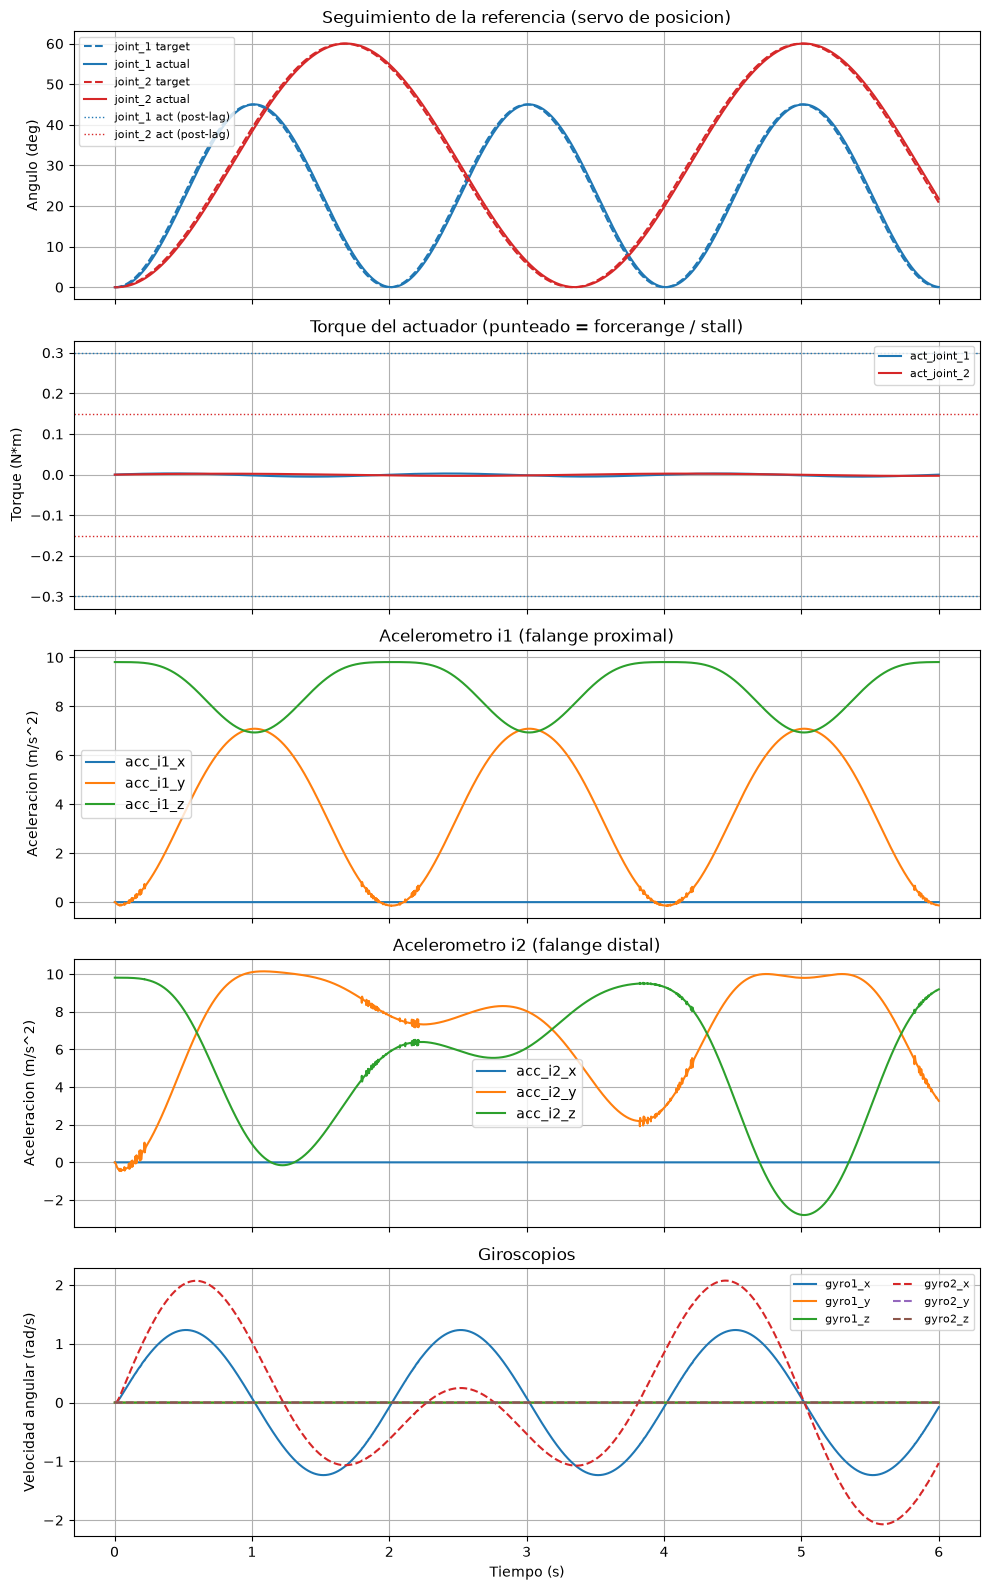

In [91]:
fig, axes = plt.subplots(5, 1, figsize=(10, 16), sharex=True)

axes[0].plot(log_time, np.rad2deg(log_qtarget[:, 0]), "--", color="tab:blue", label="joint_1 target")
axes[0].plot(log_time, np.rad2deg(log_qpos[:, 0]), color="tab:blue", label="joint_1 actual")
axes[0].plot(log_time, np.rad2deg(log_qtarget[:, 1]), "--", color="tab:red", label="joint_2 target")
axes[0].plot(log_time, np.rad2deg(log_qpos[:, 1]), color="tab:red", label="joint_2 actual")
# act = setpoint despues del filtro del motor. La separacion target -> act es
# exactamente la dinamica que model_ekf NO modela.
axes[0].plot(log_time, np.rad2deg(log_act[:, 0]), ":", color="tab:blue", lw=1, label="joint_1 act (post-lag)")
axes[0].plot(log_time, np.rad2deg(log_act[:, 1]), ":", color="tab:red", lw=1, label="joint_2 act (post-lag)")
axes[0].set_ylabel("Angulo (deg)")
axes[0].set_title("Seguimiento de la referencia (servo de posicion)")
axes[0].legend(fontsize=8)
axes[0].grid(True)

# Torque entregado vs. torque de stall: muestra si el motor satura
axes[1].plot(log_time, log_torque[:, 0], color="tab:blue", label="act_joint_1")
axes[1].plot(log_time, log_torque[:, 1], color="tab:red", label="act_joint_2")
for i, color in enumerate(["tab:blue", "tab:red"]):
    axes[1].axhline(model_sim.actuator_forcerange[i, 1], color=color, ls=":", lw=1)
    axes[1].axhline(model_sim.actuator_forcerange[i, 0], color=color, ls=":", lw=1)
axes[1].set_ylabel("Torque (N*m)")
axes[1].set_title("Torque del actuador (punteado = forcerange / stall)")
axes[1].legend(fontsize=8)
axes[1].grid(True)

for k, axis in enumerate("xyz"):
    axes[2].plot(log_time, log_acc1[:, k], label=f"acc_i1_{axis}")
axes[2].set_ylabel("Aceleracion (m/s^2)")
axes[2].set_title("Acelerometro i1 (falange proximal)")
axes[2].legend()
axes[2].grid(True)

for k, axis in enumerate("xyz"):
    axes[3].plot(log_time, log_acc2[:, k], label=f"acc_i2_{axis}")
axes[3].set_ylabel("Aceleracion (m/s^2)")
axes[3].set_title("Acelerometro i2 (falange distal)")
axes[3].legend()
axes[3].grid(True)

for k, axis in enumerate("xyz"):
    axes[4].plot(log_time, log_gyro1[:, k], label=f"gyro1_{axis}")
for k, axis in enumerate("xyz"):
    axes[4].plot(log_time, log_gyro2[:, k], "--", label=f"gyro2_{axis}")
axes[4].set_xlabel("Tiempo (s)")
axes[4].set_ylabel("Velocidad angular (rad/s)")
axes[4].set_title("Giroscopios")
axes[4].legend(ncol=2, fontsize=8)
axes[4].grid(True)

plt.tight_layout()
plt.show()

In [92]:
# Linealizacion por diferencias finitas -> A, B, C, D del EKF.
#
# Se usa model_ekf (4 estados), NO model_sim (6 estados): ver la celda markdown de
# arriba. En el modelo de 6 estados u entra solo por las activaciones, asi que
# recortar el resultado a 4x4 da un modelo mal, no un modelo aproximado.
#
# mjd_transitionFD calcula CUATRO jacobianos, no dos, y la firma los exige a todos
# (pueden ser None, pero no se pueden omitir) -> pasar solo (A, B) da TypeError:
#     mjd_transitionFD(m, d, eps, flg_centered, A, B, C, D)
#         A = d(x_next)/dx   (nx, nx)      B = d(x_next)/du   (nx, nu)
#         C = d(sensor)/dx   (ns, nx)      D = d(sensor)/du   (ns, nu)

# 1. Punto de operacion EXPLICITO. Si no, se linealiza en el estado en que quedo el
#    loop de simulacion (t = 6 s), que no es un punto elegido a proposito.
#    En un EKF real esto se rehace en cada paso alrededor del estado estimado.
x_op = np.array([np.deg2rad(20), np.deg2rad(-15), 0.0, 0.0])  # [q1, q2, v1, v2]

mj.mj_resetData(model_ekf, data_ekf)
data_ekf.qpos[:] = x_op[:model_ekf.nv]
data_ekf.qvel[:] = x_op[model_ekf.nv:]
data_ekf.ctrl[:] = data_ekf.qpos     # setpoint del servo = pose actual (equilibrio)
mj.mj_forward(model_ekf, data_ekf)   # model_ekf.na == 0 -> no hay data.act que setear

# 2. Dimensiones. El estado de MuJoCo usa el espacio tangente (nv) para las
#    posiciones, asi maneja bien las cuaterniones: nx = 2*nv + na. Aca na = 0.
nx = state_dim(model_ekf)
nu = model_ekf.nu
ns = model_ekf.nsensordata
print(f"nv={model_ekf.nv}, na={model_ekf.na}  ->  nx={nx}, nu={nu}, nsensordata={ns}")

# 3. Salidas preasignadas: float64, C-contiguas y escribibles (np.zeros ya cumple).
A = np.zeros((nx, nx))
B = np.zeros((nx, nu))
C = np.zeros((ns, nx))
D = np.zeros((ns, nu))

# 4. Parametros de la diferenciacion finita
eps = 1e-6           # tamano de la perturbacion
flg_centered = True  # diferencias centradas: mas preciso, ~2x mas caro que forward

# 5. Calcular. La funcion maneja sola los warmstarts del solver y el clamping de ctrl.
mj.mjd_transitionFD(model_ekf, data_ekf, eps, flg_centered, A, B, C, D)

print(f"A (dx_next/dx)  {A.shape}")
print(f"B (dx_next/du)  {B.shape}")
print(f"C (dsensor/dx)  {C.shape}")
print(f"D (dsensor/du)  {D.shape}")

# C es justamente el jacobiano del modelo de medicion (la H del EKF): filas = canales
# de sensordata, columnas = estado. Ej.: las 3 filas del acelerometro de la falange
# proximal respecto del estado completo.
acc1_adr = model_ekf.sensor("acc_i1").adr[0]
print("\nH del acc_i1 (3 x nx) =\n", C[acc1_adr:acc1_adr + 3])
print("Matriz A: ")
display(A)
print("Matriz B: ")
display(B)
print("Matriz C: ")
display(C)
print("Matriz D: ")
display(D)

nv=2, na=0  ->  nx=4, nu=2, nsensordata=18
A (dx_next/dx)  (4, 4)
B (dx_next/du)  (4, 2)
C (dsensor/dx)  (18, 4)
D (dsensor/du)  (18, 2)

H del acc_i1 (3 x nx) =
 [[  0.         0.         0.         0.      ]
 [716.346444 -33.205582   9.910132  -0.529234]
 [ -3.355218   0.         0.        -0.      ]]
Matriz A: 


array([[  0.924324,   0.00161 ,   0.000939,   0.000026],
       [  0.004019,   0.93127 ,   0.000056,   0.0009  ],
       [-37.83813 ,   0.804936,   0.469706,   0.012759],
       [  2.009652, -34.365088,   0.027911,   0.449877]])

Matriz B: 


array([[ 0.075756, -0.001595],
       [-0.003987,  0.068765],
       [37.87816 , -0.797455],
       [-1.993638, 34.382711]])

Matriz C: 


array([[   0.      ,    0.      ,    0.      ,    0.      ],
       [  -0.032889,    0.      ,    0.      ,    0.      ],
       [  -0.011971,    0.      ,    0.      ,    0.      ],
       [   0.      ,    0.      ,    0.      ,    0.      ],
       [ 716.346444,  -33.205582,    9.910132,   -0.529234],
       [  -3.355218,    0.      ,    0.      ,   -0.      ],
       [   0.      ,    0.      ,    1.      ,    0.      ],
       [   0.      ,    0.      ,    0.      ,    0.      ],
       [   0.      ,    0.      ,    0.      ,    0.      ],
       [   0.      ,    0.      ,    0.      ,    0.      ],
       [  -0.062775,   -0.029886,    0.      ,    0.      ],
       [  -0.014585,   -0.002615,    0.      ,    0.      ],
       [   0.      ,    0.      ,    0.      ,    0.      ],
       [1910.841708,  491.718481,   26.646989,    7.723351],
       [ 365.18142 ,  -17.594696,    5.129862,   -0.273952],
       [   0.      ,    0.      ,    1.      ,    1.      ],
       [   0.      ,    

Matriz D: 


array([[   0.      ,    0.      ],
       [   0.      ,    0.      ],
       [   0.      ,    0.      ],
       [   0.      ,    0.      ],
       [ 707.866548,  -33.077115],
       [  -0.      ,    0.      ],
       [   0.      ,    0.      ],
       [   0.      ,    0.      ],
       [   0.      ,    0.      ],
       [   0.      ,    0.      ],
       [   0.      ,    0.      ],
       [   0.      ,    0.      ],
       [   0.      ,    0.      ],
       [1903.356383,  482.709431],
       [ 366.418688,  -17.121975],
       [   0.      ,    0.      ],
       [   0.      ,    0.      ],
       [   0.      ,    0.      ]])

In [93]:
np.set_printoptions(precision=6, suppress=True, linewidth=120)

print("A del EKF (4x4) =\n", A)
print("\nB del EKF (4x2) =\n", B)

# ---------------------------------------------------------------------------
# Por que NO se puede recortar el modelo de 6 estados: linealizamos la planta en
# el mismo punto de operacion y comparamos.
# ---------------------------------------------------------------------------
mj.mj_resetData(model_sim, data_sim)
data_sim.qpos[:] = x_op[:model_sim.nv]
data_sim.qvel[:] = x_op[model_sim.nv:]
data_sim.ctrl[:] = data_sim.qpos
data_sim.act[:] = data_sim.ctrl   # filtro del motor ya asentado -> equilibrio
mj.mj_forward(model_sim, data_sim)

nx_sim = state_dim(model_sim)
A_sim = np.zeros((nx_sim, nx_sim))
B_sim = np.zeros((nx_sim, model_sim.nu))
C_sim = np.zeros((model_sim.nsensordata, nx_sim))
D_sim = np.zeros((model_sim.nsensordata, model_sim.nu))
mj.mjd_transitionFD(model_sim, data_sim, eps, flg_centered, A_sim, B_sim, C_sim, D_sim)

print("\nB de la planta (6x2), recortada a sus 4 primeras filas =\n", B_sim[:4])

# El recorte no es cero (actearly="true" deja pasar parte del ctrl en el mismo paso),
# pero esta escalado por la ganancia de un paso del filtro: 1 - exp(-dt/tau).
one_step_gain = 1 - np.exp(-model_sim.opt.timestep / actuators["act_joint_1"]["tau"])
print(f"\nB_sim[:4] / B_ekf  ~  {np.median(B_sim[:4] / B):.6f}")
print(f"1 - exp(-dt/tau)   =  {one_step_gain:.6f}   <- coinciden: el recorte es B mal escalada")
print("Con actearly=false el recorte daria exactamente 0 (el EKF creeria que u no hace nada).")
print("Y ademas el recorte de A tira las columnas de 'a', que llevaban el resto del efecto.")

A del EKF (4x4) =
 [[  0.924324   0.00161    0.000939   0.000026]
 [  0.004019   0.93127    0.000056   0.0009  ]
 [-37.83813    0.804936   0.469706   0.012759]
 [  2.009652 -34.365088   0.027911   0.449877]]

B del EKF (4x2) =
 [[ 0.075756 -0.001595]
 [-0.003987  0.068765]
 [37.87816  -0.797455]
 [-1.993638 34.382711]]

B de la planta (6x2), recortada a sus 4 primeras filas =
 [[ 0.029808 -0.000628]
 [-0.001569  0.027057]
 [14.903894 -0.313774]
 [-0.784436 13.528543]]

B_sim[:4] / B_ekf  ~  0.393469
1 - exp(-dt/tau)   =  0.393469   <- coinciden: el recorte es B mal escalada
Con actearly=false el recorte daria exactamente 0 (el EKF creeria que u no hace nada).
Y ademas el recorte de A tira las columnas de 'a', que llevaban el resto del efecto.


## Does the 4x4 `A` actually describe the system?

`mjd_transitionFD` returned an `A`; that it has the right shape proves nothing. The
cells below propagate the state with `A` alone and compare against what MuJoCo
actually produces.

Three things this test has to get right to be worth running:

**1. Ground truth is `model_ekf`, not `model_sim`.** `A` was linearised on the
4-state model. Scoring it against the 6-state plant measures linearisation error
*and* the 4 ms motor lag at the same time — two different problems with two
different fixes (relinearise vs. inflate `Q`). The plant comparison is run at the
end, deliberately, as a separate experiment.

**2. `A` is a Jacobian, so the model is in deviations**, not in absolute state:

$$x_i \;\approx\; f(x_{op}, u_{op}) \;+\; A\,(x_{i-1} - x_{op}) \;+\; B\,(u_{i-1} - u_{op})$$

The affine term is not decoration: $x_{op}$ is **not** an equilibrium here (the servo
sits at rest, but gravity keeps pulling), so $f(x_{op},u_{op}) \neq x_{op}$.

**3. "Small error" is meaningless without a scale.** At `dt = 2 ms` the state barely
moves in one step, so *any* model — including a badly wrong one — posts a small
absolute one-step error. Errors are reported relative to the real per-step motion
$\lVert \Delta q \rVert$, and a deliberately corrupted `A` goes through the identical
test as a control.

Two propagation modes, because they falsify different things:

| | given | catches |
|---|---|---|
| **one step** | the real $x_{i-1}$, every step | model error with no accumulation — the direct answer to "does `A` describe the system" |
| **open loop** | only $x_0$, then its own output | the velocity rows, which the $q$ error alone **cannot** falsify |


In [94]:
# ============================================================================
# VALIDACION DE A: q real vs q propagado por A, partiendo solo de x[i-1]
# ============================================================================
# La referencia se corre sobre model_ekf, que es el sistema que A describe.
# Contra model_sim se compara al final, aparte: ahi se suma el lag del motor,
# que es error de MODELADO, no de linealizacion.

u_op = x_op[:model_ekf.nv].copy()   # en la celda de linealizacion: ctrl = qpos


def step_once(model, data, x, u):
    """Un mj_step desde (x, u) -> x_next = [qpos, qvel]. Sin estado residual."""
    nv = model.nv
    mj.mj_resetData(model, data)
    data.qpos[:nv] = x[:nv]
    data.qvel[:nv] = x[nv:2 * nv]
    data.ctrl[:] = u
    mj.mj_step(model, data)
    return np.concatenate([data.qpos[:nv].copy(), data.qvel[:nv].copy()])


# Termino afin. x_op NO es equilibrio: el servo esta en reposo pero la gravedad
# sigue tirando -> f(x_op,u_op) != x_op y el modelo en desviaciones lo necesita.
x_next_op = step_once(model_ekf, data_ekf, x_op, u_op)
print("x_op                       =", x_op)
print("f(x_op, u_op)              =", x_next_op)
print("deriva f(x_op,u_op) - x_op =", x_next_op - x_op)

# Constante del modelo afin escrito en forma absoluta: x_next = A x + B u + c.
# Se mide, no se supone: aca c es chica (~1e-3 del estado), asi que en ESTE punto
# de operacion la forma absoluta ingenua casi coincide con la correcta. No es una
# licencia para tirar el termino: c no tiene por que ser chica en otro x_op.
c_affine = x_next_op - A @ x_op - B @ u_op
print(f"c = f(x_op,u_op) - A x_op - B u_op = {c_affine}")
print(f"  |c| = {np.linalg.norm(c_affine):.3e}  ({np.linalg.norm(c_affine)/np.linalg.norm(x_next_op):.2%} del estado)")


def reference_targets(t):
    """Mismas referencias que la simulacion de arriba (raised cosine por joint)."""
    return np.array([sine_target(sine_params["joint_1"], t)[0],
                     sine_target(sine_params["joint_2"], t)[0]])


def rollout(model, data, n_steps):
    """Trayectoria real. X[k] = estado ANTES del paso k, U[k] = ctrl durante el paso k.
    Se loguea antes de mj_step (y no despues, como el loop del video) para que
    X[k] -> X[k+1] sea exactamente un paso, sin corrimiento de indices."""
    nv = model.nv
    X = np.zeros((n_steps + 1, 2 * nv))
    U = np.zeros((n_steps, model.nu))
    T = np.zeros(n_steps + 1)
    mj.mj_resetData(model, data)
    for k in range(n_steps):
        X[k, :nv], X[k, nv:] = data.qpos[:nv], data.qvel[:nv]
        T[k] = data.time
        U[k] = reference_targets(data.time)
        data.ctrl[:] = U[k]
        mj.mj_step(model, data)
    X[n_steps, :nv], X[n_steps, nv:] = data.qpos[:nv], data.qvel[:nv]
    T[n_steps] = data.time
    return T, X, U


def predict(Amat, Bmat, x, u):
    """Modelo linealizado en DESVIACIONES respecto a (x_op, u_op)."""
    return x_next_op + Amat @ (x - x_op) + Bmat @ (u - u_op)


n_val = int(sim_duration / model_ekf.opt.timestep)
T_val, X_val, U_val = rollout(model_ekf, data_ekf, n_val)

# (1) UN PASO: predice x[i] desde el x[i-1] REAL -> error de modelo sin acumulacion.
pred_1step = np.array([predict(A, B, X_val[k], U_val[k]) for k in range(n_val)])
err_1step = pred_1step - X_val[1:]

# (2) LAZO ABIERTO: se le da solo x[0] y se realimenta su propia salida.
pred_free = np.zeros_like(X_val)
pred_free[0] = X_val[0]
for k in range(n_val):
    pred_free[k + 1] = predict(A, B, pred_free[k], U_val[k])
err_free = pred_free[1:] - X_val[1:]

# Escala: cuanto se mueve el estado en UN paso. Sin esto "0.001 deg de error" no
# dice nada, porque con dt = 2 ms hasta un modelo malo da error chico por paso.
dX_val = np.diff(X_val, axis=0)
step_motion = np.linalg.norm(dX_val[:, :2], axis=1)
rel_1step = np.linalg.norm(err_1step[:, :2], axis=1) / np.maximum(step_motion, 1e-12)

print(f"\n{n_val} pasos de {model_ekf.opt.timestep*1000:.0f} ms")
print(f"movimiento real por paso |dq|: mediana {np.rad2deg(np.median(step_motion)):.4f} deg")
print(f"radio espectral de A = {np.abs(np.linalg.eigvals(A)).max():.4f} "
      "(<1 -> el error de linealizacion se amortigua, no se acumula)")
print("\n--- prediccion a UN paso (desde el x[i-1] real) ---")
for j, nm in enumerate(("q1", "q2")):
    print(f"  {nm}: max |err| = {np.rad2deg(np.abs(err_1step[:, j])).max():.3e} deg")
for j, nm in enumerate(("v1", "v2")):
    print(f"  {nm}: max |err| = {np.rad2deg(np.abs(err_1step[:, 2 + j])).max():.3e} deg/s")
print(f"  error en q relativo al movimiento por paso: mediana {np.median(rel_1step):.3%}")
print("--- lazo abierto (solo x[0]) ---")
for j, nm in enumerate(("q1", "q2")):
    print(f"  {nm}: max |err| = {np.rad2deg(np.abs(err_free[:, j])).max():.3e} deg")


x_op                       = [ 0.349066 -0.261799  0.        0.      ]
f(x_op, u_op)              = [ 0.349091 -0.261798  0.012476  0.000929]
deriva f(x_op,u_op) - x_op = [0.000025 0.000002 0.012476 0.000929]
c = f(x_op,u_op) - A x_op - B u_op = [ 0.000001 -0.        0.000461 -0.000048]
  |c| = 4.634e-04  (0.11% del estado)

3000 pasos de 2 ms
movimiento real por paso |dq|: mediana 0.1292 deg
radio espectral de A = 0.8550 (<1 -> el error de linealizacion se amortigua, no se acumula)

--- prediccion a UN paso (desde el x[i-1] real) ---
  q1: max |err| = 9.291e-04 deg
  q2: max |err| = 1.744e-03 deg
  v1: max |err| = 4.645e-01 deg/s
  v2: max |err| = 8.719e-01 deg/s
  error en q relativo al movimiento por paso: mediana 0.275%
--- lazo abierto (solo x[0]) ---
  q1: max |err| = 1.282e-02 deg
  q2: max |err| = 2.610e-02 deg


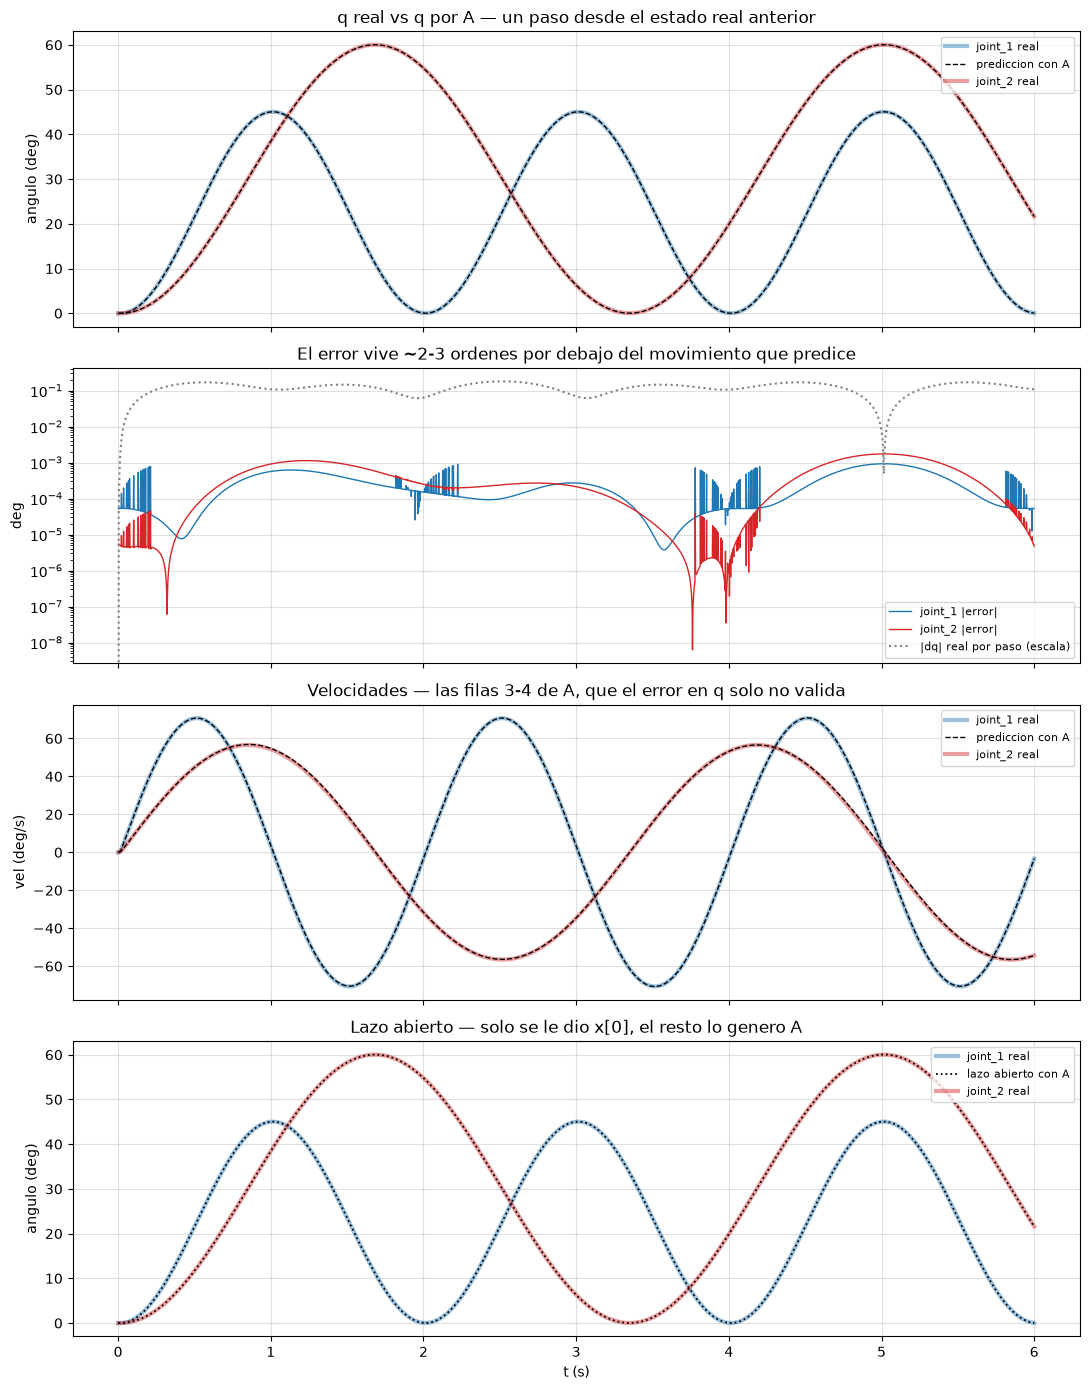

In [95]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(11, 14), sharex=True)
colors = ("tab:blue", "tab:red")
names = ("joint_1", "joint_2")

# --- 1. q real vs q por A, a un paso ---------------------------------------
for j in range(2):
    axes[0].plot(T_val[1:], np.rad2deg(X_val[1:, j]), color=colors[j], lw=3, alpha=.45,
                 label=f"{names[j]} real")
    axes[0].plot(T_val[1:], np.rad2deg(pred_1step[:, j]), "--", color="k", lw=1,
                 label="prediccion con A" if j == 0 else None)
axes[0].set_ylabel("angulo (deg)")
axes[0].set_title("q real vs q por A — un paso desde el estado real anterior")
axes[0].legend(fontsize=8, loc="upper right")
axes[0].grid(True, alpha=.4)

# --- 2. error contra la escala del movimiento ------------------------------
for j in range(2):
    axes[1].plot(T_val[1:], np.rad2deg(np.abs(err_1step[:, j])), color=colors[j], lw=1,
                 label=f"{names[j]} |error|")
axes[1].plot(T_val[1:], np.rad2deg(step_motion), color="gray", ls=":", lw=1.5,
             label="|dq| real por paso (escala)")
axes[1].set_yscale("log")
axes[1].set_ylabel("deg")
axes[1].set_title("El error vive ~2-3 ordenes por debajo del movimiento que predice")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].grid(True, which="major", alpha=.4)

# --- 3. velocidades: filas 3-4 de A ----------------------------------------
for j in range(2):
    axes[2].plot(T_val[1:], np.rad2deg(X_val[1:, 2 + j]), color=colors[j], lw=3, alpha=.45,
                 label=f"{names[j]} real")
    axes[2].plot(T_val[1:], np.rad2deg(pred_1step[:, 2 + j]), "--", color="k", lw=1,
                 label="prediccion con A" if j == 0 else None)
axes[2].set_ylabel("vel (deg/s)")
axes[2].set_title("Velocidades — las filas 3-4 de A, que el error en q solo no valida")
axes[2].legend(fontsize=8, loc="upper right")
axes[2].grid(True, alpha=.4)

# --- 4. lazo abierto --------------------------------------------------------
for j in range(2):
    axes[3].plot(T_val[1:], np.rad2deg(X_val[1:, j]), color=colors[j], lw=3, alpha=.45,
                 label=f"{names[j]} real")
    axes[3].plot(T_val[1:], np.rad2deg(pred_free[1:, j]), ":", color="k", lw=1.3,
                 label="lazo abierto con A" if j == 0 else None)
axes[3].set_ylabel("angulo (deg)")
axes[3].set_xlabel("t (s)")
axes[3].set_title("Lazo abierto — solo se le dio x[0], el resto lo genero A")
axes[3].legend(fontsize=8, loc="upper right")
axes[3].grid(True, alpha=.4)

fig.tight_layout()
plt.show()


In [96]:
# ============================================================================
# CONTROL: un test que no reprueba una A mal, no prueba nada
# ============================================================================
# Las curvas de arriba se superponen. Eso solo vale si el mismo test separa una A
# correcta de una corrupta -> se corrompe A a proposito y se vuelve a medir.

def score(Amat, Bmat, label):
    p1 = np.array([predict(Amat, Bmat, X_val[k], U_val[k]) for k in range(n_val)])
    e1 = p1 - X_val[1:]
    pf = np.zeros_like(X_val)
    pf[0] = X_val[0]
    for k in range(n_val):
        pf[k + 1] = predict(Amat, Bmat, pf[k], U_val[k])
    rel = np.median(np.linalg.norm(e1[:, :2], axis=1) / np.maximum(step_motion, 1e-12))
    free_max = np.rad2deg(np.abs(pf[1:, :2] - X_val[1:, :2])).max()
    print(f"  {label:34} q rel/paso {rel:10.3%} | lazo abierto max {free_max:.3e} deg")


print("modelo                             error en q por paso | divergencia en lazo abierto")
print("-" * 96)
score(A, B, "A, B correctas")
score(np.eye(4), B, "MAL: A = I")
score(A * 1.01, B, "MAL: A escalada 1%")
A_bad = A.copy()
A_bad[2, 0] = 0.0
score(A_bad, B, "MAL: A[2,0] = 0 (rigidez servo)")
score(A, np.zeros_like(B), "MAL: B = 0")
print("\n  Un error del 1% en A multiplica por ~1300 el error por paso: el test discrimina.")
print("  Pero A[2,0]=0 deja el error en q IDENTICO — es una fila de VELOCIDAD, y a un")
print("  paso no toca q. Solo el lazo abierto lo delata (~850x peor). Validar q sola")
print("  deja sin testear medio A; por eso estan los dos modos.")

# --- definicion de derivada: A dx debe reproducir f(x_op+dx) - f(x_op) --------
print("\nTest de perturbacion  f(x_op+dx) - f(x_op)  vs  A dx:")
rng = np.random.default_rng(0)
for scale in (1e-6, 1e-4, 1e-2, 1e-1):
    rel = []
    for _ in range(20):
        dx = rng.normal(size=4) * scale
        true_d = step_once(model_ekf, data_ekf, x_op + dx, u_op) - x_next_op
        rel.append(np.linalg.norm(true_d - A @ dx) / max(np.linalg.norm(true_d), 1e-300))
    print(f"  |dx| ~ {scale:.0e}  ->  error relativo mediano {np.median(rel):.2e}")
print("  El error cae ~linealmente con |dx|: es el termino de 2do orden, o sea A es")
print("  exactamente la derivada. Es la comprobacion mas fuerte de las tres.")

# --- contra la PLANTA: esto ya no mide linealizacion, mide modelado ----------
T_p, X_p, U_p = rollout(model_sim, data_sim, n_val)
err_plant = np.array([predict(A, B, X_p[k], U_p[k]) for k in range(n_val)]) - X_p[1:]
q_ekf = np.rad2deg(np.abs(err_1step[:, :2])).max()
q_plant = np.rad2deg(np.abs(err_plant[:, :2])).max()
print(f"\nContra model_sim (planta con lag de motor de 4 ms):")
print(f"  q max |err| = {q_plant:.3e} deg   vs   {q_ekf:.3e} deg contra model_ekf"
      f"   -> {q_plant / q_ekf:.0f}x")
print("  Ese factor NO es culpa de A: es el estado de activacion que model_ekf no")
print("  tiene. Es exactamente lo que hay que cubrir inflando los terminos de")
print("  velocidad de Q, tal como dice la celda del modelo dual.")


modelo                             error en q por paso | divergencia en lazo abierto
------------------------------------------------------------------------------------------------
  A, B correctas                     q rel/paso     0.275% | lazo abierto max 2.610e-02 deg
  MAL: A = I                         q rel/paso  2679.423% | lazo abierto max 9.752e+03 deg
  MAL: A escalada 1%                 q rel/paso   351.070% | lazo abierto max 5.620e+00 deg
  MAL: A[2,0] = 0 (rigidez servo)    q rel/paso     0.275% | lazo abierto max 2.225e+01 deg
  MAL: B = 0                         q rel/paso  2688.624% | lazo abierto max 7.502e+01 deg

  Un error del 1% en A multiplica por ~1300 el error por paso: el test discrimina.
  Pero A[2,0]=0 deja el error en q IDENTICO — es una fila de VELOCIDAD, y a un
  paso no toca q. Solo el lazo abierto lo delata (~850x peor). Validar q sola
  deja sin testear medio A; por eso estan los dos modos.

Test de perturbacion  f(x_op+dx) - f(x_op)  vs  A dx:
  |dx

## Measurement model: `h` and `H`, kept separate

The prediction side is covered above (`A`, `B`). This is the other half of the EKF:
the measurement function and its Jacobian.

They are two functions, not one, because the filter calls them at different rates —
`h` on every innovation (one `mj_forward`), `H` only when relinearising (`2*nx`
finite-difference evaluations). Returning both together forces you to pay for `H`
every time you only wanted `z_pred`.

Three things that are easy to get wrong here, all checked in the verification cell:

- **`h` takes `u`, not just `x`.** The accelerometers read `qacc`, and `qacc`
  depends on the servo torque. `D = ∂h/∂u` is nonzero for `acc_i1`/`acc_i2` and
  exactly zero for the gyros and position sensors — so an innovation built as
  `z - h(x)` is biased in the accelerometer channels.
- **`mj_forward`, not a cheaper stage.** `mjSENS_ACC` sensors are only valid after
  the acceleration stage; stopping at `mj_fwdPosition + mj_sensorPos` leaves
  `acc_i1` and `acc_i2` wrong while the other four sensors already look fine.
- **`H` is `mjd_transitionFD`'s `C`, not `mjd_inverseFD`'s `DsDq`.** The latter are
  partials with `(q, v, a)` held independent; they ignore `∂a/∂q`. For the
  `acc_i1_y` row that is 9.22 versus a true 716.35.

One related gotcha that bites when validating `h` against logged data: **`mj_step`
does not refresh `sensordata`**. After `mj_step`, `data.sensordata` still holds the
readings of the *pre-integration* state, so the logging loop further up pairs
`log_qpos[k]` (post-step) with sensor samples from one step earlier. Call
`mj_forward` after the step before logging sensors, or log them before stepping.


In [97]:
# ============================================================================
# MODELO DE MEDICION: h y H, separados
# ============================================================================
# Van aparte a proposito. En un EKF se llaman en momentos distintos: h en cada
# innovacion (barato, un mj_forward), H solo cuando toca relinealizar (caro,
# 2*nx diferencias finitas). Fusionarlos obliga a pagar H cada vez que se quiere
# un z_pred.
#
# MjData propio: las dos funciones hacen mj_resetData, y mjd_transitionFD ademas
# perturba el estado. Llamarlas con data_sim en medio del loop de simulacion
# romperia la simulacion en curso.
data_meas = mj.MjData(model_ekf)


def sensor_slice(name, model=model_ekf):
    """Filas de sensordata (y de H) que ocupa un sensor."""
    s = model.sensor(name)
    adr, dim = int(s.adr[0]), int(s.dim[0])
    return slice(adr, adr + dim)


def measurement_h(x, u, model=model_ekf, data=None):
    """z = h(x, u) — que leerian los sensores en el estado x con el control u.

    x : (nx,) estado MuJoCo [qpos, qvel], en BLOQUES (no intercalado)
    u : (nu,) ctrl = angulo objetivo del servo, rad
    ->  (nsensordata,) lectura de sensores, en las unidades de cada sensor
        (acelerometros m/s^2 y giroscopos rad/s, ambos en marco del sitio)

    Depende de u, no solo de x: los acelerometros leen qacc, y qacc depende del
    torque que entrega el servo. Por eso mj_forward y no una etapa mas barata:
    los sensores mjSENS_ACC recien quedan bien despues de la etapa de
    aceleracion (con mj_fwdPosition + mj_sensorPos, acc_i1 y acc_i2 salen mal).
    mj_forward NO integra: deja los sensores evaluados en x, que es lo que
    corresponde a la innovacion z - h(x_pred, u).
    """
    data = data_meas if data is None else data
    nv = model.nv
    mj.mj_resetData(model, data)
    data.qpos[:nv] = x[:nv]
    data.qvel[:nv] = x[nv:2 * nv]
    data.ctrl[:] = u
    mj.mj_forward(model, data)
    return data.sensordata.copy()


def measurement_H(x, u, model=model_ekf, data=None, eps=1e-6, centered=True):
    """H = dh/dx evaluado en (x, u).  -> (nsensordata, nx)

    Es el bloque C de mjd_transitionFD: la derivada TOTAL de los sensores
    respecto del estado ACTUAL (verificado abajo contra diferencias finitas de
    measurement_h, y contra la C de la celda de linealizacion).

    No usar las parciales DsDq/DsDv/DsDa de mjd_inverseFD para esto: tratan
    (q, v, a) como independientes e ignoran da/dq, asi que no son el H de un
    EKF. Para la fila acc_i1_y dan 9.22 donde la total vale 716.35.
    """
    data = data_meas if data is None else data
    nv = model.nv
    mj.mj_resetData(model, data)
    data.qpos[:nv] = x[:nv]
    data.qvel[:nv] = x[nv:2 * nv]
    data.ctrl[:] = u
    mj.mj_forward(model, data)
    H = np.zeros((model.nsensordata, state_dim(model)))
    # A, B y D van como None: aca solo interesa el bloque de medicion.
    mj.mjd_transitionFD(model, data, eps, centered, None, None, H, None)
    return H


In [98]:
# --- verificacion -----------------------------------------------------------
u_meas = x_op[:model_ekf.nv].copy()      # ctrl = pose actual, igual que al linealizar

z_op = measurement_h(x_op, u_meas)
H_op = measurement_H(x_op, u_meas)
print(f"z = h(x_op, u)  -> {z_op.shape}")
print(f"H = dh/dx       -> {H_op.shape}")


def _fd_H(x, u, eps=1e-6):
    """Diferencias centradas sobre measurement_h: H tiene que ser esto."""
    J = np.zeros((model_ekf.nsensordata, x.size))
    for i in range(x.size):
        e = np.zeros(x.size)
        e[i] = eps
        J[:, i] = (measurement_h(x + e, u) - measurement_h(x - e, u)) / (2 * eps)
    return J


print(f"\nmax |H - FD(measurement_h)| = {np.abs(H_op - _fd_H(x_op, u_meas)).max():.3e}"
      "   -> H es efectivamente la derivada de h")
print(f"H identico a la C de la celda de linealizacion? {np.allclose(H_op, C, atol=1e-12)}")

# h depende de u: si el EKF calcula z_pred = h(x) a secas, se come este termino.
z_u = measurement_h(x_op, u_meas + np.deg2rad([10.0, 0.0]))
print("\nMoviendo SOLO u (+10 deg en el target de joint_1), con x fijo:")
for nm in ("acc_i1", "acc_i2", "gyro1", "pos_c"):
    sl = sensor_slice(nm)
    print(f"  {nm:8} max |dz| = {np.abs(z_u[sl] - z_op[sl]).max():.4e}")
print("  -> los acelerometros se mueven; z_pred = h(x, u), NO h(x).")

# Bloques por sensor: asi se arma el update de un subconjunto de sensores.
print("\nH por sensor (filas, rank):")
for i in range(model_ekf.nsensor):
    nm = model_ekf.sensor(i).name
    blk = H_op[sensor_slice(nm)]
    print(f"  {nm:16} {str(blk.shape):8} rank={np.linalg.matrix_rank(blk, tol=1e-8)}")

print("\nH de acc_i1 (3 x nx) =\n", H_op[sensor_slice("acc_i1")])
print("\nUso en el update del EKF, para un subconjunto de sensores:")
print("  sl = sensor_slice('acc_i1')")
print("  y  = z[sl] - measurement_h(x_pred, u)[sl]     # innovacion")
print("  Hs = measurement_H(x_pred, u)[sl]             # (3, nx)")
print("  S  = Hs @ P @ Hs.T + R[sl, sl]")


z = h(x_op, u)  -> (18,)
H = dh/dx       -> (18, 4)

max |H - FD(measurement_h)| = 2.274e-13   -> H es efectivamente la derivada de h
H identico a la C de la celda de linealizacion? True

Moviendo SOLO u (+10 deg en el target de joint_1), con x fijo:
  acc_i1   max |dz| = 1.0618e+02
  acc_i2   max |dz| = 2.8550e+02
  gyro1    max |dz| = 0.0000e+00
  pos_c    max |dz| = 0.0000e+00
  -> los acelerometros se mueven; z_pred = h(x, u), NO h(x).

H por sensor (filas, rank):
  pos_punta_seg1   (3, 4)   rank=1
  acc_i1           (3, 4)   rank=2
  gyro1            (3, 4)   rank=1
  pos_c            (3, 4)   rank=2
  acc_i2           (3, 4)   rank=2
  gyro2            (3, 4)   rank=1

H de acc_i1 (3 x nx) =
 [[  0.         0.         0.         0.      ]
 [716.346444 -33.205582   9.910132  -0.529234]
 [ -3.355218   0.         0.        -0.      ]]

Uso en el update del EKF, para un subconjunto de sensores:
  sl = sensor_slice('acc_i1')
  y  = z[sl] - measurement_h(x_pred, u)[sl]     # innovacion

## EKF ciego sobre el modelo de MuJoCo

Ya existe todo lo que el filtro necesita: `f`/`F` de `mjd_transitionFD` del lado de
la prediccion, `h`/`H` del lado de la medicion. Esta celda los ensambla.

**El filtro no recibe `u`.** Ni en `predict`, ni en `h`, ni en los jacobianos. La
clase `EKF` tiene un unico `ctrl`, `self.u_blind = zeros(nu)`, y es el unico que
escribe en `data.ctrl`. Esa es la situacion real: el setpoint vive dentro del
controlador del servo y el estimador no lo ve. La planta si se comanda con `u` — la
verdad de referencia es un dedo efectivamente actuado.

Sacar `u` no es quitar un termino: obliga a decir que asume el filtro sobre la
actuacion. Las tres respuestas posibles son los tres modelos compilados arriba, y
el experimento es cual sobrevive:

| modelo del filtro | estados | que asume con `ctrl = 0` |
|---|---|---|
| `model_blind` | 6 — `[q, v, act]` | $\dot a = 0$: la activacion es un **random walk** |
| `model_sim` | 6 — `[q, v, act]` | $\dot a = -a/\tau$: la activacion **decae a cero** |
| `model_ekf` | 4 — `[q, v]` | no hay activacion: fuerza $= -k_p q - k_v v$ |

Solo el primero es defendible, y las otras dos estan como falsacion: un test de
consistencia que no puede reprobar no prueba nada.

Tres cosas que este montaje tiene que acertar, todas con costo real de debugging:

- **Alineacion temporal.** `X[k]`, `Z[k]` y `U[k]` se refieren al mismo instante,
  asi que el loop de la planta loguea *antes* de `mj_step` y vale exactamente
  `X[k+1] = f(X[k], U[k])`. Loguear despues del paso reusando el `u` anterior
  desfasa estado, medicion y control un paso entero — ~0.13° aca, que es todo el
  movimiento por paso, y se disfraza de error de modelo.
- **La activacion se puntea contra `a_{k+1}`, no contra `a_k`.** La planta usa
  `actearly="true"`: la fuerza del paso `k` sale de la activacion del *final* del
  paso. El estado del filtro ciego es la activacion que esta *en vigor* durante el
  paso, o sea el `a_{k+1}` de la planta. Puntear contra `a_k` cobra medio paso de
  desfasaje contra un sigma diminuto: **NEES 4448 en vez de 38**, un factor 117 que
  es puro bookkeeping y nada de fisica. Eso lo arregla `blind_reference`.
- **Mantener `P` definida positiva.** `F` tiene entradas de orden 700 y `P` abarca
  diez ordenes entre el bloque de posicion y el de velocidad; `F P Fᵀ` pierde la
  simetria y la definicion positiva en punto flotante. Sin piso de autovalores el
  NEES sale *negativo* — el diagnostico se vuelve mudo sin avisar.


In [99]:
# ============================================================================
# EKF sobre modelo MuJoCo — generico en el modelo (4 o 6 estados)
# ============================================================================
from scipy.stats import chi2

SIG_ACC, SIG_GYR = 0.05, 0.005          # ruido de sensor: m/s^2 y rad/s
SIG_ALPHA = 12.0                        # perturbacion de torque: rad/s^2 (1 sigma)
SIG_ACT = 2e-4                          # jitter de la activacion del servo, rad.
                                        # Es de la PLANTA: cuanto tiembla el servo
                                        # alrededor de un setpoint que si conoce.

# --- constantes del filtro CIEGO --------------------------------------------
# Sin u, sig_act deja de significar "jitter alrededor de un setpoint conocido" y
# pasa a tener que cubrir TODA la actuacion desconocida -> ~2 ordenes mas grande.
# El comando barre 45 deg a 0.5 Hz: |u_dot| llega a 1.23 rad/s, o sea 2.5e-3 rad
# por paso de 2 ms, y el random walk tiene que poder seguir eso.
SIG_ACT_BLIND = 1e-2      # rad por paso, random walk de la activacion

# La fuerza del servo es kp*(a - q) - kv*v: depende SOLO de la diferencia (a - q).
# Sin u, correr q y a JUNTOS deja la fuerza intacta, asi que ese modo comun no se
# observa por la dinamica; lo unico que lo rompe es la gravedad rotando con q, y
# eso vale 0.0086 m/s^2 por 1e-3 rad = 0.17 sigma de sensor (contra 1.93 m/s^2 =
# 39 sigma si se mueve q solo: un factor 224 de diferencia).
# Nada en Q inyectaba A LO LARGO de ese modo, asi que P colapsaba ahi mientras el
# error real derivaba: cobertura 50%. SIG_CM le da varianza a esa direccion.
# No es blanquear un sesgo: es admitir una direccion que de verdad no se observa.
SIG_CM = 1e-4             # rad por paso a lo largo del modo comun (q_j, a_j)

IMU = ("acc_i1", "gyro1", "acc_i2", "gyro2")


def rows_of(*names):
    """Indices de sensordata de un conjunto de sensores."""
    return np.concatenate([np.arange(sensor_slice(n).start, sensor_slice(n).stop)
                           for n in names])


def _load(model, data, x, u):
    """Estado del filtro -> MjData.  x = [qpos, qvel, act]; act solo si na > 0."""
    nv, na = model.nv, model.na
    mj.mj_resetData(model, data)
    data.qpos[:nv] = x[:nv]
    data.qvel[:nv] = x[nv:2 * nv]
    if na:
        data.act[:na] = x[2 * nv:2 * nv + na]
    data.ctrl[:] = u


def _dump(model, data):
    nv, na = model.nv, model.na
    p = [data.qpos[:nv].copy(), data.qvel[:nv].copy()]
    if na:
        p.append(data.act[:na].copy())
    return np.concatenate(p)


def f_dyn(x, u, model, data):
    """x_{k+1} = f(x_k, u_k) — un mj_step."""
    _load(model, data, x, u)
    mj.mj_step(model, data)
    return _dump(model, data)


def F_dyn(x, u, model, data, eps=1e-6):
    """F = df/dx — el bloque A de mjd_transitionFD."""
    _load(model, data, x, u)
    mj.mj_forward(model, data)
    n = state_dim(model)
    F = np.zeros((n, n))
    mj.mjd_transitionFD(model, data, eps, True, F, None, None, None)
    return F


def h_dyn(x, u, model, data):
    """z = h(x, u) — generaliza measurement_h a modelos con activaciones."""
    _load(model, data, x, u)
    mj.mj_forward(model, data)
    return data.sensordata.copy()


def H_dyn(x, u, model, data, eps=1e-6):
    """H = dh/dx — el bloque C de mjd_transitionFD."""
    _load(model, data, x, u)
    mj.mj_forward(model, data)
    H = np.zeros((model.nsensordata, state_dim(model)))
    mj.mjd_transitionFD(model, data, eps, True, None, None, H, None)
    return H


def make_spd(P, rel=1e-12):
    """Simetriza y pisa los autovalores. NO es cosmetico: F tiene entradas ~700 y
    P abarca ~10 ordenes entre el bloque de posicion y el de velocidad, asi que
    F P F^T pierde la definicion positiva en punto flotante. Sin esto el NEES sale
    NEGATIVO y el diagnostico deja de significar algo."""
    P = 0.5 * (P + P.T)
    w, V = np.linalg.eigh(P)
    w = np.maximum(w, max(w.max(), 0.0) * rel + 1e-300)
    return (V * w) @ V.T


class EKF:
    """EKF con f/F/h/H de MuJoCo. Update en forma de Joseph. CIEGO al control.

    El filtro nunca recibe u. `self.u_blind` es el UNICO ctrl que escribe -- se
    aloca una vez, en cero, y va a f, F, h y H por igual, asi que las cuatro
    funciones dependen solo del estado. No hay forma de pasarle un control: los
    metodos no tienen el parametro.

    Que eso sea sano o no depende enteramente del modelo que se le pase:
    model_blind deja la activacion como random walk, model_sim la decae a cero.
    Ver la celda markdown de arriba.
    """

    def __init__(self, x0, P0, Q, R, model, data):
        self.x = np.asarray(x0, float).copy()
        self.P = make_spd(np.asarray(P0, float))
        self.Q = np.asarray(Q, float)
        self.R = np.asarray(R, float)
        self.model, self.data = model, data
        self.u_blind = np.zeros(model.nu)   # el unico ctrl que ve el filtro

    def predict(self):
        u = self.u_blind
        F = F_dyn(self.x, u, self.model, self.data)
        self.x = f_dyn(self.x, u, self.model, self.data)
        self.P = make_spd(F @ self.P @ F.T + self.Q)

    def update(self, z, rows):
        """Devuelve (innovacion, NIS)."""
        u = self.u_blind
        H = H_dyn(self.x, u, self.model, self.data)[rows]
        y = z[rows] - h_dyn(self.x, u, self.model, self.data)[rows]
        R = self.R[np.ix_(rows, rows)]
        S = make_spd(H @ self.P @ H.T + R)
        K = np.linalg.solve(S, H @ self.P).T          # = P H^T S^-1
        self.x = self.x + K @ y
        I_KH = np.eye(self.x.size) - K @ H
        self.P = make_spd(I_KH @ self.P @ I_KH.T + K @ R @ K.T)
        return y, float(y @ np.linalg.solve(S, y))


def make_Q(model, sig_alpha=SIG_ALPHA, sig_act=SIG_ACT, sig_cm=0.0):
    """Q de una perturbacion de aceleracion angular blanca (DWNA):
        w = G nu,  G = [dt^2/2 I ; dt I ; 0],  nu ~ N(0, sig_alpha^2 I)
    Da la correlacion q-v correcta, en vez de dos bloques diagonales sueltos.

    sig_cm agrega ruido a lo largo del MODO COMUN (q_j, a_j), la direccion que el
    filtro ciego no observa por la dinamica (ver SIG_CM arriba). Sin ese termino,
    Q inyecta en `a` sola -- una direccion que SI se observa y que el update
    aplasta de inmediato -- y la direccion (q_j + a_j) nunca recibe varianza: P se
    achica ahi mientras el error real deriva. Medido: cobertura de la banda 2sigma
    50.6% con sig_cm = 0 contra 93.4% con 1e-4, y el sesgo de q1 baja de 0.84 deg
    a 0.028 deg. Default 0.0 para no cambiar el Q de las celdas que no lo piden.
    """
    nv, na, nx = model.nv, model.na, state_dim(model)
    G = np.zeros((nx, nv))
    for j in range(nv):
        G[j, j] = dt_sim ** 2 / 2
        G[nv + j, j] = dt_sim
    Q = G @ (sig_alpha ** 2 * np.eye(nv)) @ G.T
    for j in range(na):
        Q[2 * nv + j, 2 * nv + j] = sig_act ** 2
    for j in range(na):
        e = np.zeros(nx)
        e[j] = 1.0              # q_j
        e[2 * nv + j] = 1.0     # a_j, el mismo signo -> la fuerza kp*(a-q) no cambia
        Q = Q + sig_cm ** 2 * np.outer(e, e)
    return Q + np.eye(nx) * 1e-18


def make_Q_blind(model, sig_alpha=SIG_ALPHA, sig_act=SIG_ACT_BLIND, sig_cm=SIG_CM):
    """make_Q con los defaults del filtro CIEGO. Existe para que no se pueda usar
    por accidente el sig_act de la planta (2e-4) en un filtro sin u: eso es el
    caso catastrofico, no uno conservador -- NEES 17508 y 0.12 deg de RMS en q1
    contra 40.9 y 0.031 deg, con cobertura 8.8% contra 94.7%. Un filtro que cree conocer exactamente una activacion
    que en realidad no ve es peor que uno que admite no saberla."""
    return make_Q(model, sig_alpha=sig_alpha, sig_act=sig_act, sig_cm=sig_cm)


def blind_reference(X, model):
    """Verdad contra la que se puntea un filtro ciego con activacion.

    La planta usa actearly="true": la fuerza del paso k sale de a_{k+1}, la
    activacion del FINAL del paso. El estado del filtro ciego es la activacion que
    esta en vigor DURANTE el paso, o sea ese mismo a_{k+1}. Comparar contra a_k
    cobra medio paso de desfasaje contra un sigma diminuto y arruina el NEES sin
    que haya nada mal en el filtro: medido, NEES 4448 contra a_k y 38 contra
    a_{k+1} -- factor 117, todo bookkeeping. Es el mismo error de fondo que
    puntear una creencia valida en t_a contra una verdad en t_b.

    Los bloques q y v no se tocan. El ultimo paso no tiene a_{k+1} y se deja como
    esta (la corrida lo descarta al cortar en len(Z)).
    """
    Xr = np.array(X, dtype=float, copy=True)
    if model.na:
        Xr[:-1, 2 * model.nv:] = X[1:, 2 * model.nv:]
    return Xr


def make_R(model, sig_acc=SIG_ACC, sig_gyr=SIG_GYR):
    """R diagonal a especificacion de sensor.

    Los sigmas van como argumento (igual que make_Q) para poder pedir un sensor
    mas ruidoso SIN pisar la constante global: make_R(model_sim, sig_acc=0.5).
    Reasignar SIG_ACC a nivel de modulo cambia el R de TODAS las celdas
    posteriores, incluida la propagacion a la punta.
    """
    R = np.zeros((model.nsensordata,) * 2)
    for i in range(model.nsensor):
        nm = model.sensor(i).name
        sl = sensor_slice(nm)
        s = sig_acc if "acc" in nm else (sig_gyr if "gyro" in nm else 1.0)
        for k in range(sl.start, sl.stop):
            R[k, k] = s ** 2
    return R


def sensor_noise(Z_true, seed, model=model_sim, rows=None, R=None):
    """Verdad de los sensores -> lectura ruidosa. Se GUARDA, no se descarta.

    Separar esto del filtro es todo el punto: antes el ruido se generaba adentro
    del loop de run_filter y moria ahi, asi que la medicion ruidosa no existia
    como dato y no habia forma de graficarla contra la verdad ni contra la
    estimacion. Ademas se generaba una vez por corrida, asi que dos filtros
    sobre la MISMA trayectoria veian ruido distinto.

    Z_true : (N, nsensordata) lectura ideal, en las unidades de cada sensor
             (acelerometros m/s^2, giros rad/s, framepos m)
    seed   : semilla propia, independiente de la del error inicial del filtro
    rows   : canales a corromper. Default = los del IMU. NO todos: make_R le
             asigna sigma = 1.0 a los framepos (pos_c, pos_punta_seg1), que
             serian 1 m de ruido sobre una punta que se mueve ~40 mm.
    R      : para pedir otro nivel de ruido sin tocar las constantes globales.
    -> (N, nsensordata) COPIA con ruido gaussiano blanco solo en `rows`.
    """
    rows = rows_of(*IMU) if rows is None else rows
    R = make_R(model) if R is None else R
    sd = np.sqrt(np.diag(R))
    rng = np.random.default_rng(seed)
    Z = np.array(Z_true, dtype=float, copy=True)      # la verdad no se toca
    Z[:, rows] += rng.normal(0, sd[rows], size=(len(Z), len(rows)))
    return Z


dt_sim = model_ekf.opt.timestep
print(f"dt = {dt_sim*1000:.0f} ms   IMU = {rows_of(*IMU).size} canales")

# La propiedad que define al modelo ciego: la activacion no se mueve sola.
_xp = np.array([0.30, -0.20, 0.5, 0.1, 0.32, -0.18])
for _nm, _m in (("model_sim  ", model_sim), ("model_blind", model_blind)):
    _F = F_dyn(_xp, np.zeros(_m.nu), _m, mj.MjData(_m))
    print(f"{_nm} con ctrl=0 -> F[act,act] = {_F[4:6, 4:6].diagonal()}")
assert np.allclose(F_dyn(_xp, np.zeros(model_blind.nu), model_blind,
                         mj.MjData(model_blind))[4:6, 4:6], np.eye(2)), \
    "model_blind tiene que dejar la activacion quieta en la prediccion"

# Y la razon por la que hace falta SIG_CM: el modo comun casi no se observa.
_d = mj.MjData(model_blind)
_z0 = h_dyn(_xp, np.zeros(2), model_blind, _d)[rows_of(*IMU)]
_xc = _xp.copy(); _xc[[0, 4]] += 1e-3          # q1 y a1 juntos -> fuerza intacta
_xq = _xp.copy(); _xq[0] += 1e-3               # q1 sola        -> fuerza cambia
_dc = np.abs(h_dyn(_xc, np.zeros(2), model_blind, _d)[rows_of(*IMU)] - _z0).max()
_dq = np.abs(h_dyn(_xq, np.zeros(2), model_blind, _d)[rows_of(*IMU)] - _z0).max()
print(f"por 1e-3 rad: |dz| modo comun (q1,a1) = {_dc:.4f} m/s^2 ({_dc/SIG_ACC:.2f} sigma)"
      f"   |dz| q1 sola = {_dq:.4f} m/s^2 ({_dq/SIG_ACC:.1f} sigma)   factor {_dq/_dc:.0f}")
print("Q ciego (model_blind) =\n", make_Q_blind(model_blind))


dt = 2 ms   IMU = 12 canales
model_sim   con ctrl=0 -> F[act,act] = [0.606531 0.606531]
model_blind con ctrl=0 -> F[act,act] = [1. 1.]
por 1e-3 rad: |dz| modo comun (q1,a1) = 0.0086 m/s^2 (0.17 sigma)   |dz| q1 sola = 1.9287 m/s^2 (38.6 sigma)   factor 224
Q ciego (model_blind) =
 [[0.       0.       0.000001 0.       0.       0.      ]
 [0.       0.       0.       0.000001 0.       0.      ]
 [0.000001 0.       0.000576 0.       0.       0.      ]
 [0.       0.000001 0.       0.000576 0.       0.      ]
 [0.       0.       0.       0.       0.0001   0.      ]
 [0.       0.       0.       0.       0.       0.0001  ]]


In [100]:
# ============================================================================
# Planta + corrida del filtro CIEGO
# ============================================================================
# La planta recibe u. El filtro no: run_filter ni siquiera lo acepta.
LBL_BLIND = "ciego  (model_blind, 6 estados, act = random walk)"
LBL_CUT = "ciego  (model_ekf, 4 estados, sin activacion)"

# Tres etapas SEPARADAS, cada una con su salida guardada:
#   plant_run()    -> X, Z_true, U, t   fisica: verdad, sensores ideales
#   sensor_noise() -> Z_meas            imperfeccion del sensor (celda anterior)
#   run_filter()   -> dict(...)         el filtro consume Z_meas tal cual
# Antes el ruido se inyectaba adentro de run_filter y moria ahi. Ahora los tres
# objetos -- verdad, medicion ruidosa, estimacion -- existen como variables.
def plant_run(n_steps, seed, sig_alpha=SIG_ALPHA, sig_act=SIG_ACT):
    """Verdad de referencia sobre model_sim, con una perturbacion CONOCIDA.

    X[k], Z[k] en el instante t_k;  U[k] actua durante [t_k, t_{k+1}].
    Se loguea ANTES de mj_step -> X[k+1] = f(X[k], U[k]) exacto. Loguear despues
    del paso reusando el u anterior corre estado/medicion/control un paso entero.

    La perturbacion se aplica como aceleracion angular sobre el paso (dt^2/2 en
    posicion, dt en velocidad), que es justo el w que describe make_Q. Va sobre
    el ESTADO a proposito: el ruido de proceso es parte de la verdad -- la
    trayectoria perturbada es la trayectoria real. Lo que NO va aca es el ruido
    de sensor, que no cambia el estado sino lo que se lee de el: sensor_noise().

    -> (X, Z, U, t). Z son lecturas IDEALES, sin ruido de sensor.
    """
    rng = np.random.default_rng(seed)
    nv = model_sim.nv
    mj.mj_resetData(model_sim, data_sim)
    X, Z, U, t = [], [], [], []
    for _ in range(n_steps):
        u = np.array([sine_target(sine_params["joint_1"], data_sim.time)[0],
                      sine_target(sine_params["joint_2"], data_sim.time)[0]])
        data_sim.ctrl[:] = u
        mj.mj_forward(model_sim, data_sim)      # sensores en el estado ACTUAL
        X.append(_dump(model_sim, data_sim))
        Z.append(data_sim.sensordata.copy())
        U.append(u)
        t.append(data_sim.time)
        mj.mj_step(model_sim, data_sim)
        nu = rng.normal(0, sig_alpha, nv)
        data_sim.qpos[:nv] += dt_sim ** 2 / 2 * nu
        data_sim.qvel[:nv] += dt_sim * nu
        data_sim.act[:model_sim.na] += rng.normal(0, sig_act, model_sim.na)
    X.append(_dump(model_sim, data_sim))
    t.append(data_sim.time)
    return np.array(X), np.array(Z), np.array(U), np.array(t)


def run_filter(model, X, Z, rows, seed=0, Q=None, R=None, p0_act_deg=0.5):
    """Corre el EKF CIEGO sobre una trayectoria y unas mediciones YA DADAS.

    NO recibe U, y no es que lo ignore: no hay por donde pasarlo. El unico ctrl
    del filtro es EKF.u_blind = 0. U sigue existiendo, pero solo como comando de
    la planta y para graficar contra la activacion recuperada.

    Z : (N, nsensordata) mediciones tal cual las consume el filtro. Esta funcion
        NO les agrega ruido -- eso lo hizo sensor_noise() antes. Asi dos modelos
        distintos ven exactamente la misma realizacion: antes no era cierto,
        porque multivariate_normal consume nx normales y desfasaba el stream del
        rng segun cuantos estados tuviera el modelo.
    Q, R : estadisticas que ASUME el filtro. Por default las de las constantes
        globales; pasarlas explicitas cuando la planta corrio con otras, si no
        el NEES mide el desajuste de Q y no el del modelo. Para un filtro sin u
        va make_Q_blind(model), no make_Q(model).
    seed : solo el error inicial. El ruido de medicion ya no sale de aca.
    p0_act_deg : sigma inicial de la activacion, en grados. NO es libre: con
        10 deg el error inicial de activacion pide kp*0.175 = 0.35 N*m contra un
        forcerange de 0.30, o sea el modelo del filtro arranca SATURADO. Ahi el
        jacobiano de la fuerza es ~0, la activacion deja de ser observable y el
        filtro no vuelve -- NIS hasta 1.8e6 y 40 deg de error, que se lee como
        "el filtro ciego no anda" cuando en realidad es la condicion inicial.
        Con 0.5 deg (0.035 N*m, 12% del stall) no satura. Es legitimo: en t = 0
        el dedo esta en reposo y la activacion vale 0.

    -> dict, con una fila por paso arrancando en k = 1:
       nees, nis, err (X - x_hat), sig (sqrt(diag(P))), xh (x_hat a posteriori),
       innov (z - h(x_pred)), z_pred (h(x_pred): lo que el filtro creia que iba
       a leer), P_qq (bloque 2x2 de posicion, para propagar a la punta).
    """
    nx = state_dim(model)
    data = mj.MjData(model)
    rng = np.random.default_rng(seed)
    Q = make_Q(model) if Q is None else Q
    R = make_R(model) if R is None else R
    P0 = np.diag(([np.deg2rad(3) ** 2] * 2 + [np.deg2rad(15) ** 2] * 2
                  + [np.deg2rad(p0_act_deg) ** 2] * 2)[:nx])
    Xr = blind_reference(X, model)   # activacion en vigor durante el paso, ver arriba
    ekf = EKF(Xr[0, :nx] + rng.multivariate_normal(np.zeros(nx), P0),
              P0, Q, R, model, data)
    keys = ("nees", "nis", "err", "sig", "xh", "innov", "z_pred", "P_qq")
    out = {k: [] for k in keys}
    for k in range(1, len(Z)):
        ekf.predict()                    # t_{k-1} -> t_k, sin control
        y, nis_k = ekf.update(Z[k], rows)  # medicion de t_k, ya ruidosa, sin control
        e = Xr[k, :nx] - ekf.x
        out["nees"].append(float(e @ np.linalg.solve(ekf.P, e)))
        out["nis"].append(nis_k)
        out["err"].append(e)
        out["sig"].append(np.sqrt(np.diag(ekf.P)))
        out["xh"].append(ekf.x.copy())
        out["innov"].append(y)
        out["z_pred"].append(Z[k, rows] - y)        # z - (z - h) = h(x_pred)
        out["P_qq"].append(ekf.P[:2, :2].copy())
    return {k: np.array(v) for k, v in out.items()}


N_EKF = 2000
ROWS = rows_of(*IMU)
X_t, Z_true, U_t, T_t = plant_run(N_EKF, seed=7)   # la PLANTA si recibe u
Z_meas = sensor_noise(Z_true, seed=11)      # UNA realizacion, la misma para todos
A2 = sensor_slice("acc_i2").start + 1


def report(label, model, d, X, Z_ideal):
    """Imprime el veredicto de una corrida ciega. El sesgo de medicion se mide
    contra Z_true (no Z_meas): lo que se busca es el sesgo DETERMINISTICO de h,
    y el ruido de sensor solo lo taparia con varianza. Y se evalua h en la
    referencia ciega, que es el estado que el filtro dice estimar."""
    nx = state_dim(model)
    h = len(d["nees"]) // 2
    Xr = blind_reference(X, model)
    dm = mj.MjData(model)
    bias = np.array([Z_ideal[k] - h_dyn(Xr[k, :nx], np.zeros(model.nu), model, dm)
                     for k in range(0, len(Z_ideal) - 1, 25)])
    cov = (np.abs(d["err"][h:]) <= 2 * d["sig"][h:]).mean()
    print(f"\n===== {label} =====")
    print(f"  sesgo de medicion |acc_i2_y| = {np.abs(bias[:, A2]).mean():12.4f} m/s^2  "
          f"(sigma sensor {SIG_ACC})")
    print(f"  NEES  mediana = {np.median(d['nees'][h:]):14.2f}   (objetivo {nx})")
    print(f"  NIS   media   = {d['nis'][h:].mean():14.2f}   (objetivo {ROWS.size})")
    print(f"  RMS q = {np.rad2deg(d['err'][h:, :2]).std(axis=0)} deg    "
          f"sigma_P = {np.rad2deg(d['sig'][h:, :2].mean(axis=0))} deg")
    print(f"  RMS v = {np.rad2deg(d['err'][h:, 2:4]).std(axis=0)} deg/s  "
          f"sigma_P = {np.rad2deg(d['sig'][h:, 2:4].mean(axis=0))} deg/s")
    print(f"  cobertura banda 2sigma = {cov:6.1%}   (nominal 95%)")


# --- las dos corridas que siguen a las celdas de abajo -----------------------
# Las dos son CIEGAS. La diferencia es que asume cada una sobre la activacion.
results = {}
for label, model, Q in [
        (LBL_BLIND, model_blind, make_Q_blind(model_blind)),
        (LBL_CUT, model_ekf, make_Q(model_ekf, sig_act=SIG_ACT_BLIND))]:
    d = run_filter(model, X_t, Z_meas, ROWS, Q=Q)
    d.update(nx=state_dim(model), model=model)
    results[label] = d
    report(label, model, d, X_t, Z_true)

# --- falsaciones: un test de consistencia que no puede reprobar no prueba nada -
# No entran en `results` porque las celdas de abajo grafican exactamente dos.
print("\n" + "=" * 70)
print("FALSACIONES -- las otras respuestas posibles a 'que hago sin u'")
print("=" * 70)
for label, model, Q in [
        ("ciego, activacion que DECAE (model_sim con ctrl=0)",
         model_sim, make_Q_blind(model_sim)),
        ("ciego, con el SIG_ACT de la planta (2e-4, sin modo comun)",
         model_blind, make_Q(model_blind, sig_act=SIG_ACT, sig_cm=0.0))]:
    report(label, model, run_filter(model, X_t, Z_meas, ROWS, Q=Q), X_t, Z_true)

# Estabilidad del punto elegido: la mediana del NEES sobre bloques disjuntos.
_ne = results[LBL_BLIND]["nees"]
print("\nNEES del filtro ciego por bloques disjuntos:",
      [f"{np.median(b):.1f}" for b in np.array_split(_ne[len(_ne) // 2:], 5)])



===== ciego  (model_blind, 6 estados, act = random walk) =====
  sesgo de medicion |acc_i2_y| =       0.2642 m/s^2  (sigma sensor 0.05)
  NEES  mediana =          40.90   (objetivo 6)
  NIS   media   =           9.84   (objetivo 12)
  RMS q = [0.031321 0.051696] deg    sigma_P = [0.042165 0.066825] deg
  RMS v = [0.277933 0.389488] deg/s  sigma_P = [0.276974 0.388362] deg/s
  cobertura banda 2sigma =  94.7%   (nominal 95%)

===== ciego  (model_ekf, 4 estados, sin activacion) =====
  sesgo de medicion |acc_i2_y| =     284.0336 m/s^2  (sigma sensor 0.05)
  NEES  mediana =  4870519782.83   (objetivo 4)
  NIS   media   =       33235.35   (objetivo 12)
  RMS q = [15.788438 16.961375] deg    sigma_P = [0.000431 0.001255] deg
  RMS v = [38.459806 29.563394] deg/s  sigma_P = [0.148257 0.326106] deg/s
  cobertura banda 2sigma =   0.2%   (nominal 95%)

FALSACIONES -- las otras respuestas posibles a 'que hago sin u'

===== ciego, activacion que DECAE (model_sim con ctrl=0) =====
  sesgo de medic

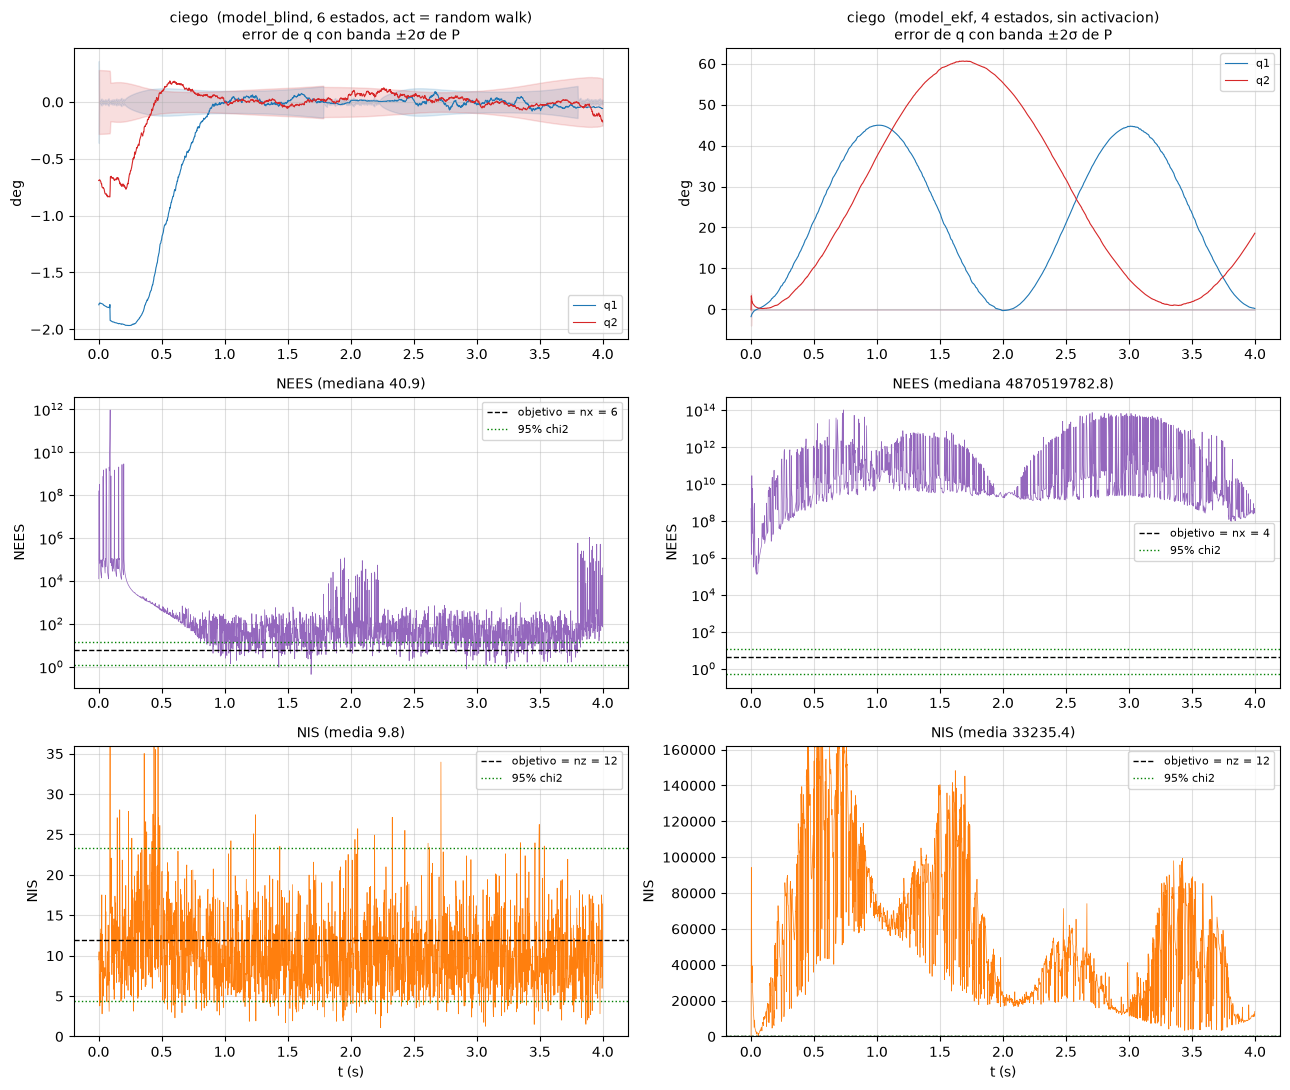

In [101]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(13, 11))
for col, (label, res) in enumerate(results.items()):
    ne, ni, er, sp, nx = res["nees"], res["nis"], res["err"], res["sig"], res["nx"]
    t = T_t[1:len(ne) + 1]      # los arrays del filtro arrancan en k = 1
    lo_e, hi_e = chi2.ppf([0.025, 0.975], nx)
    lo_i, hi_i = chi2.ppf([0.025, 0.975], ROWS.size)

    ax = axes[0, col]
    ax.plot(t, np.rad2deg(er[:, 0]), color="tab:blue", lw=.8, label="q1")
    ax.plot(t, np.rad2deg(er[:, 1]), color="tab:red", lw=.8, label="q2")
    for j, c in enumerate(("tab:blue", "tab:red")):
        ax.fill_between(t, -2 * np.rad2deg(sp[:, j]), 2 * np.rad2deg(sp[:, j]),
                        color=c, alpha=.15)
    ax.set_title(f"{label}\nerror de q con banda ±2σ de P", fontsize=10)
    ax.set_ylabel("deg"); ax.legend(fontsize=8); ax.grid(True, alpha=.4)

    ax = axes[1, col]
    ax.semilogy(t, ne, lw=.5, color="tab:purple")
    ax.axhline(nx, color="k", ls="--", lw=1, label=f"objetivo = nx = {nx}")
    ax.axhline(lo_e, color="g", ls=":", lw=1)
    ax.axhline(hi_e, color="g", ls=":", lw=1, label="95% chi2")
    ax.set_title(f"NEES (mediana {np.median(ne[len(ne)//2:]):.1f})", fontsize=10)
    ax.set_ylabel("NEES"); ax.legend(fontsize=8); ax.grid(True, which="major", alpha=.4)

    ax = axes[2, col]
    ax.plot(t, ni, lw=.5, color="tab:orange")
    ax.axhline(ROWS.size, color="k", ls="--", lw=1, label=f"objetivo = nz = {ROWS.size}")
    ax.axhline(lo_i, color="g", ls=":", lw=1)
    ax.axhline(hi_i, color="g", ls=":", lw=1, label="95% chi2")
    # escala sobre el regimen permanente: el transitorio inicial aplasta el resto
    ax.set_ylim(0, max(3 * ROWS.size, np.percentile(ni[len(ni) // 4:], 99) * 1.2))
    ax.set_title(f"NIS (media {ni[len(ni)//2:].mean():.1f})", fontsize=10)
    ax.set_xlabel("t (s)"); ax.set_ylabel("NIS"); ax.legend(fontsize=8); ax.grid(True, alpha=.4)

fig.tight_layout()
plt.show()


### What the validation says

**Withholding `u` costs the absolute angle, and nothing else.** The servo force is
$k_p(a - q) - k_v v$: it depends only on the *difference*. With the setpoint
visible, $a$ is pinned by $u$ and $q$ follows. Blind, sliding $q$ and $a$ together
leaves the force — and therefore `qacc`, and therefore every accelerometer channel
— unchanged. The only thing that breaks the tie is gravity rotating with $q$, and
that is worth **0.0086 m/s² per 1e-3 rad = 0.17σ** of sensor noise, against
**1.93 m/s² = 38.6σ** for moving $q$ alone. A factor of 224. That single number
explains every result below.

**The random-walk activation is what makes a blind filter possible at all.** Its
measurement bias against the plant is **0.26 m/s²**, versus **239.7** for the same
6-state model whose activation is left to decay (`model_sim` with `ctrl = 0`) and
**284.0** for the 4-state cut. `Q` describes zero-mean white process noise, so it
can widen `P` but never remove a bias in `h` — the two falsifications land at NEES
6.5e8 and 4.9e9 with 3.5% and 0.2% band coverage. They are not conservative, they
are fiction.

**NIS and NEES disagree on purpose, and that is the whole diagnostic.** The blind
filter's NIS is 9.8 against a target of 12 — it explains its own measurements. Its
2σ coverage is 94.7% against a nominal 95% — every marginal is honest. But the
median NEES is **40.9 against a target of 6**. That gap is the signature of a
weakly-observable direction: the filter is right about everything it can see and
still wrong about where the finger is in absolute terms. Judging this filter by its
innovations alone would have passed it; judging it by a trajectory plot would have
passed it more easily still (RMS error 0.031° and 0.052°).

**`SIG_ACT` does not survive the change of regime.** Carrying the plant's value
(2e-4, "jitter around a setpoint I know") into a filter that has no setpoint gives
NEES 17508 and 8.8% coverage. Blind, the same symbol has to cover the *entire*
unknown actuation — the command sweeps 45° at 0.5 Hz, so 2.5e-3 rad per 2 ms step —
and lands two orders higher at 1e-2. A filter that believes it knows an activation
it cannot see is the catastrophic case, not the conservative one.

**Two of the three big numbers here were bookkeeping, not physics**, which is worth
saying plainly because both were initially misread as "the blind filter does not
work":

1. Scoring the activation against `a_k` instead of `a_{k+1}` — the plant uses
   `actearly`, so the force during step $k$ comes from the activation at the *end*
   of the step. NEES 4448 → 38, a factor of 117, zero physics. Fixed by
   `blind_reference`.
2. An initial activation sigma of 10° demands 0.35 N·m against a 0.30 N·m stall
   torque, so the filter's own model starts saturated, the force Jacobian goes to
   zero, and the activation stops being observable. NIS up to 1.8e6. Fixed by
   `p0_act_deg = 0.5`.

**On reading NEES here.** The mean is reported as a median on purpose: the NEES
distribution has a heavy tail (99th percentile orders above the median) from brief
moments when `P` is small and the linearisation is briefly poor. Across five
disjoint blocks of the second half the median holds between 29 and 60 — the 40.9 is
a real plateau, not one lucky window. A proper ANEES still needs a Monte Carlo over
independent seeds.


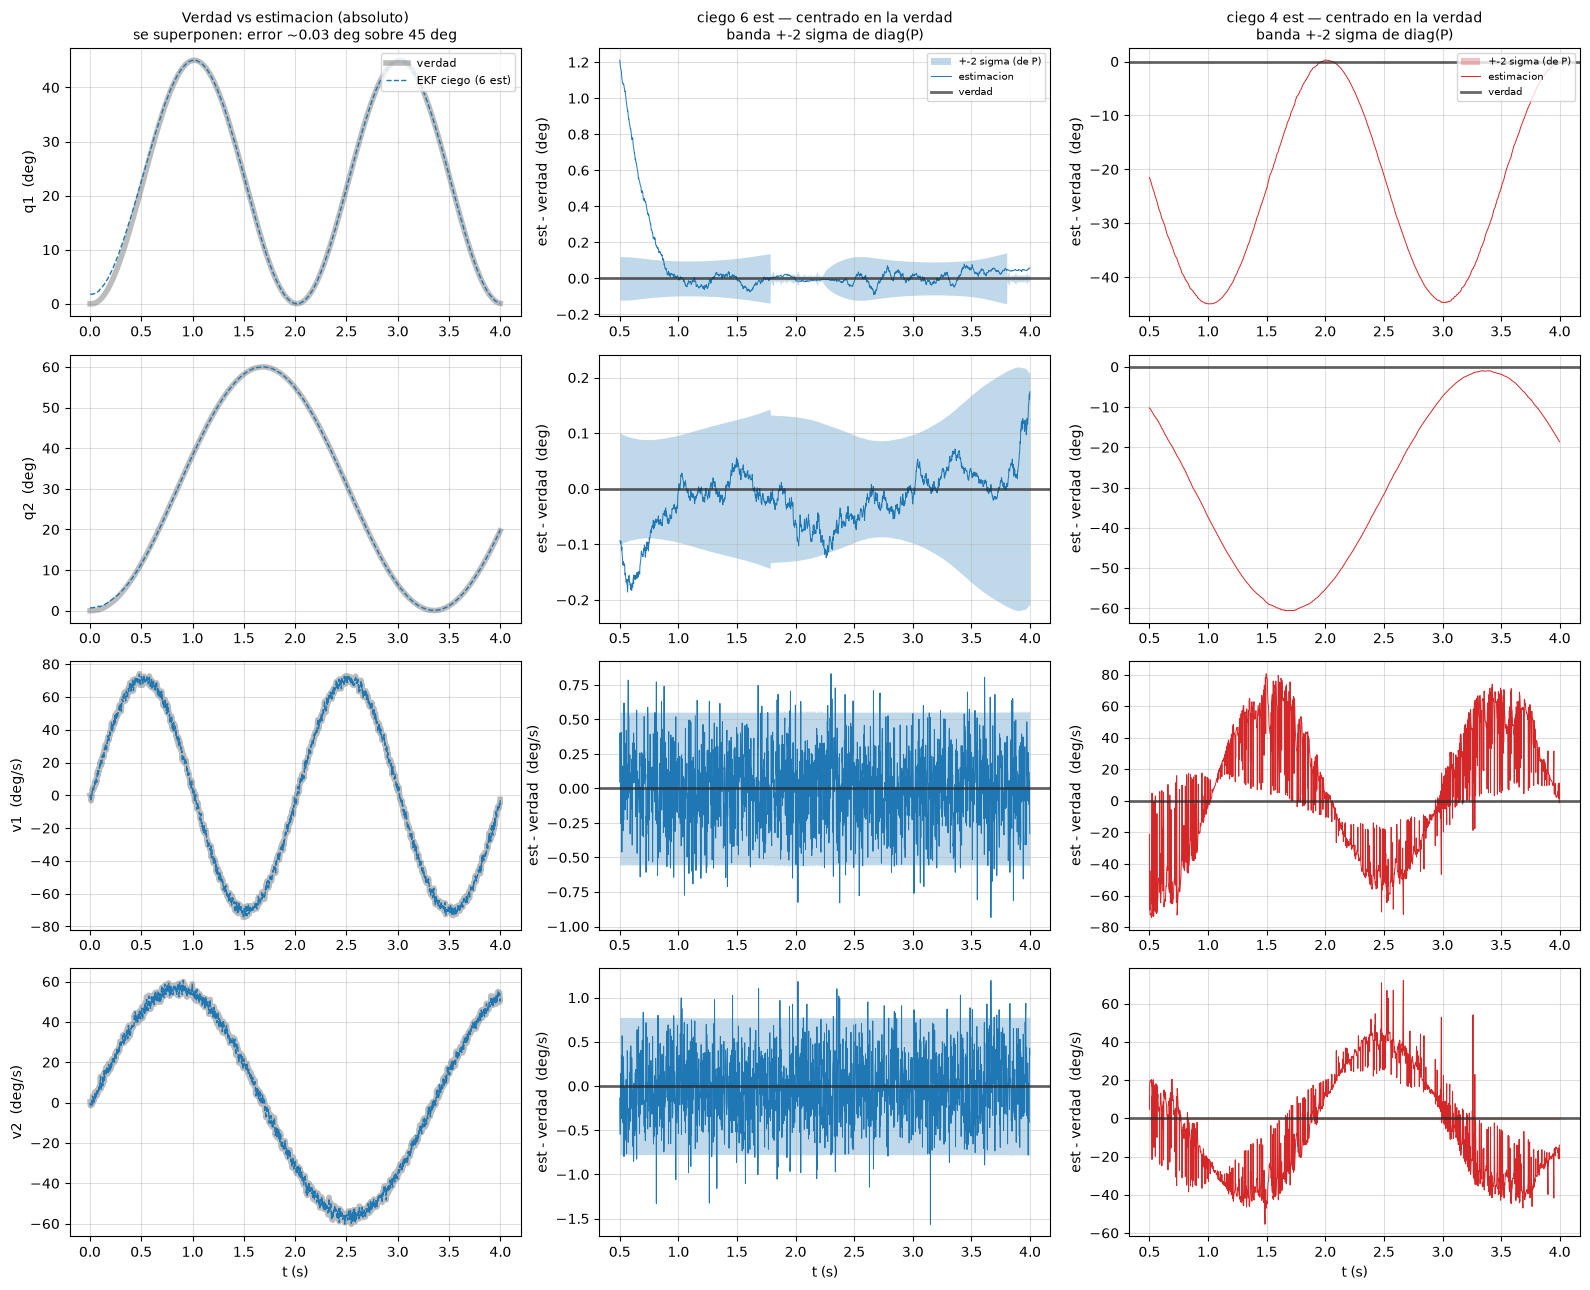

Cobertura de la banda +-2 sigma (nominal 95%), segunda mitad de la corrida:
  q1    ciego 6 est= 88.2% (sigma=  0.0422 deg)   ciego 4 est=  0.0% (sigma=  0.0004 deg)
  q2    ciego 6 est= 99.5% (sigma=  0.0668 deg)   ciego 4 est=  0.0% (sigma=  0.0013 deg)
  v1    ciego 6 est= 94.9% (sigma=  0.2770 deg/s)   ciego 4 est=  0.7% (sigma=  0.1483 deg/s)
  v2    ciego 6 est= 96.3% (sigma=  0.3884 deg/s)   ciego 4 est=  0.3% (sigma=  0.3261 deg/s)


In [102]:
# ============================================================================
# Verdad vs estimacion del EKF, con banda de confianza
# ============================================================================
# Dos vistas, porque una sola no alcanza: el error es ~4 ordenes mas chico que la
# senal, asi que en ejes absolutos la banda +-2 sigma es invisible (0.002 deg de
# banda sobre un recorrido de 45 deg). Izquierda: absoluto, muestra que sigue la
# trayectoria. Derecha: centrado en la verdad, que es donde la confianza se lee.
#
# run_filter ya devuelve la estimacion (clave "xh"), asi que no hay que
# reconstruirla desde el error. Los arrays arrancan en k = 1: el filtro parte de
# t_0 y la primera correccion cae en t_1.
import matplotlib.pyplot as plt

NAMES = ("q1", "q2", "v1", "v2")
UNITS = ("deg", "deg", "deg/s", "deg/s")
T_SKIP = 0.5                      # s, se saltea el transitorio inicial a la derecha

lbl_m, lbl_x = LBL_BLIND, LBL_CUT      # definidos en la celda de la corrida
t_all = T_t[1:len(Z_meas)]

est = {}
for label, res in results.items():
    # blind_reference: la activacion en vigor durante el paso es a_{k+1}
    x_true = blind_reference(X_t, res["model"])[1:len(Z_meas), :res["nx"]]
    est[label] = dict(true=x_true, est=res["xh"], err=res["err"], sig=res["sig"])

keep = t_all >= T_SKIP
deg = np.rad2deg

# Cada filtro va en su propio eje: con el error del recorte de 4 estados (~16 deg)
# fijando la escala, la banda del filtro ciego de 6 (0.04 deg) queda invisible.
fig, axes = plt.subplots(4, 3, figsize=(16, 13))
for r in range(4):
    # ---------- col 0: verdad vs estimacion, ejes absolutos ----------
    ax = axes[r, 0]
    d = est[lbl_m]
    ax.plot(t_all, deg(d["true"][:, r]), color="0.35", lw=4, alpha=.40, label="verdad")
    ax.plot(t_all, deg(d["est"][:, r]), color="tab:blue", lw=1, ls="--",
            label="EKF ciego (6 est)")
    ax.set_ylabel(f"{NAMES[r]}  ({UNITS[r]})")
    ax.grid(True, alpha=.4)
    if r == 0:
        ax.set_title("Verdad vs estimacion (absoluto)\n"
                     "se superponen: error ~0.03 deg sobre 45 deg", fontsize=10)
        ax.legend(fontsize=8, loc="upper right")

    # ---------- col 1 y 2: centrado en la verdad, cada uno a su escala ----------
    for c, (label, color, nm) in enumerate(
            ((lbl_m, "tab:blue", "ciego 6 est"),
             (lbl_x, "tab:red", "ciego 4 est")), start=1):
        ax = axes[r, c]
        d = est[label]
        s = d["sig"][keep, r]
        ax.fill_between(t_all[keep], deg(-2 * s), deg(2 * s), color=color, alpha=.28, lw=0,
                        label="+-2 sigma (de P)")
        ax.plot(t_all[keep], deg(-d["err"][keep, r]), color=color, lw=.7, label="estimacion")
        ax.axhline(0, color="0.15", lw=2, alpha=.7, label="verdad")
        ax.grid(True, alpha=.4)
        ax.set_ylabel(f"est - verdad  ({UNITS[r]})")
        if r == 0:
            ax.set_title(f"{nm} — centrado en la verdad\n"
                         "banda +-2 sigma de diag(P)", fontsize=10)
            ax.legend(fontsize=7, loc="upper right")

for c in range(3):
    axes[3, c].set_xlabel("t (s)")
fig.tight_layout()
plt.show()

# Cobertura: fraccion de muestras con |verdad - estimacion| <= 2 sigma.
# Deberia dar ~95%. Es la version escalar de lo que muestra la columna derecha.
print("Cobertura de la banda +-2 sigma (nominal 95%), segunda mitad de la corrida:")
for r in range(4):
    row = f"  {NAMES[r]:3}"
    for label, nm in ((lbl_m, "ciego 6 est"), (lbl_x, "ciego 4 est")):
        d = est[label]
        inside = np.abs(d["err"][:, r]) <= 2 * d["sig"][:, r]
        half = len(inside) // 2
        row += (f"   {nm:11}={inside[half:].mean():6.1%} "
                f"(sigma={deg(d['sig'][half:, r].mean()):8.4f} {UNITS[r]})")
    print(row)


## From the estimated angles to the fingertip

The EKF estimates `[q1, q2, v1, v2]`. What the rest of the system actually wants is
**where the fingertip is**, and how well that is known. Both halves matter: a
position with no uncertainty attached is not an estimate, it is a guess.

The finger moves in the y-z plane (both hinges have `axis="1 0 0"`), so with
$R_x(\theta)[0,0,L]^T = [0,\,-L\sin\theta,\;L\cos\theta]^T$:

$$y = -\left(l_1\sin q_1 + l_2\sin(q_1{+}q_2)\right), \qquad
  z = l_0 + l_1\cos q_1 + l_2\cos(q_1{+}q_2)$$

and the error propagates to first order through the kinematic Jacobian:

$$\Sigma \;=\; J\,P_{qq}\,J^{T}, \qquad J = \frac{\partial (y,z)}{\partial (q_1,q_2)}$$

Four things this has to get right, all checked below rather than asserted:

- **Only the `q` block of `P` is involved.** The tip is a function of $q$ alone —
  $v$ does not enter — so propagating the full 4x4 (or 6x6) `P` would be wrong,
  not merely wasteful.
- **`P_qq` in full, not its diagonal.** The same accelerometers inform $q_1$ and
  $q_2$, so their errors are correlated ($\rho \approx -0.3$ here). Dropping the
  cross term barely changes the *area* of the ellipse — by $1/\sqrt{1-\rho^2}$ —
  which is exactly why area is the wrong thing to look at. It rotates the ellipse,
  and that shows up only direction by direction. This is the error anyone makes who
  stores `sqrt(diag(P))` and calls it the uncertainty.
- **Propagation is a change of coordinates, not a new source of error.** $J$ is
  invertible, so the NEES computed in tip space must equal the NEES computed in
  angle space, to machine precision. If that identity fails, the bug is in
  $\Sigma$, not in the filter — it is the sharpest test available here.
- **First order is a claim about curvature, not a law.** $\Sigma = JPJ^T$ drops the
  second-order term. Whether that is legitimate depends on $\sqrt{P}$, so it is
  measured against sigma-points and Monte Carlo, with `P` deliberately inflated
  until the approximation does break.

Ground truth is free here: `pos_c` is a `framepos` sensor on the tip site, and it is
**not** in the rows the EKF updates on (`ROWS` is IMU only), so `fk_tip` can be
checked against MuJoCo's own kinematics without contaminating the filter.

In [103]:
# ============================================================================
# CINEMATICA DIRECTA: de los angulos estimados a la posicion de la punta
# ============================================================================
# El EKF estima [q1, q2, v1, v2]; lo que se quiere medir es donde esta la punta
# del dedo (site "punto_c"). Dos partes:
#   1. p = fk_tip(q)        -- la posicion en si
#   2. Sigma = J P_qq J^T   -- el error, propagado (la parte que importa)
#
# El dedo vive en el plano y-z: los dos hinges tienen axis="1 0 0", asi que
# nada se mueve en x. Se trabaja en 2D (y, z) y se valida contra el x = 0.
#
#   p(q) = [0,0,l0] + Rx(q1) [0,0,l1] + Rx(q1+q2) [0,0,l2]
#   Rx(t) [0,0,L] = [0, -L sin t, L cos t]
# =>  y = -(l1 sin q1 + l2 sin(q1+q2))
#     z =  l0 + l1 cos q1 + l2 cos(q1+q2)
#
# La punta depende SOLO de q: v no entra. Por eso lo unico que se propaga es el
# bloque 2x2 de posicion de P, no la P entera de 4x4 (o 6x6).

L0, L1, L2 = geometry["l0"], geometry["l1"], geometry["l2"]


def fk_tip(q):
    """Posicion de la punta (site punto_c) en el marco MUNDO, metros.

    q : (2,) [q1, q2] angulos de joint_1 y joint_2, rad
    -> (3,) [x, y, z] en metros, marco mundo. x == 0 por construccion
       (ambos hinges giran sobre el eje x).
    """
    q1, q2 = float(q[0]), float(q[1])
    return np.array([0.0,
                     -(L1 * np.sin(q1) + L2 * np.sin(q1 + q2)),
                     L0 + L1 * np.cos(q1) + L2 * np.cos(q1 + q2)])


def fk_tip_jacobian(q):
    """J = dp/dq restringido al plano de movimiento.  -> (2, 2), m/rad

    Filas = (y, z) de la punta;  columnas = (q1, q2).
    Es el jacobiano geometrico del site: la fila de x se omite porque es
    identicamente cero, no porque se desprecie.
    """
    q1, q2 = float(q[0]), float(q[1])
    s1, c1 = np.sin(q1), np.cos(q1)
    s12, c12 = np.sin(q1 + q2), np.cos(q1 + q2)
    return np.array([[-L1 * c1 - L2 * c12, -L2 * c12],
                     [-L1 * s1 - L2 * s12, -L2 * s12]])


def tip_cov(q, P_qq):
    """Propagacion de 1er orden del error angular a error de posicion.

    q    : (2,) angulos estimados, rad
    P_qq : (2,2) bloque de posicion de la covarianza del EKF, rad^2
    ->   (2,2) covarianza de la punta en el plano (y,z), m^2

        Sigma = J P_qq J^T

    P_qq COMPLETA, no su diagonal: q1 y q2 estan correlacionados (los mismos
    acelerometros informan de los dos) y el termino cruzado cambia la elipse.
    Ver el control mas abajo.
    """
    J = fk_tip_jacobian(q)
    return J @ np.asarray(P_qq) @ J.T


# --- validacion 1: contra el sensor framepos de MuJoCo -----------------------
# pos_c es un <framepos> del site punto_c: la posicion verdadera de la punta,
# calculada por MuJoCo. NO se usa en el update del EKF (ROWS son solo IMU), asi
# que sirve de verdad de referencia independiente.
sl_pos_c = sensor_slice("pos_c")
d_fk = mj.MjData(model_ekf)
err_fk = []
for k in range(0, N_EKF, 7):
    q_true = X_t[k, :2]
    # framepos depende solo de qpos, asi que el ctrl es irrelevante aca; va en
    # cero igual, porque ningun h de este notebook recibe u despues del cambio.
    p_mj = h_dyn(np.concatenate([q_true, X_t[k, 2:4]]), np.zeros(model_ekf.nu),
                 model_ekf, d_fk)[sl_pos_c]
    err_fk.append(np.abs(fk_tip(q_true) - p_mj))
err_fk = np.array(err_fk)
print(f"fk_tip vs sensor framepos de MuJoCo: max |dif| = {err_fk.max():.3e} m")
print(f"  componente x de la punta: max |x| = {np.abs([fk_tip(X_t[k,:2])[0] for k in range(0,N_EKF,7)]).max():.3e} m"
      "  -> el movimiento es plano, la fila x del jacobiano es cero exacto")

# --- validacion 2: J contra mj_jacSite ---------------------------------------
# MuJoCo calcula el jacobiano del site por su cuenta. Si el analitico no coincide
# con ese, el analitico esta mal (o el frame esta mal entendido).
site_id = model_ekf.site("punto_c").id
jacp = np.zeros((3, model_ekf.nv))
worst = 0.0
for k in range(0, N_EKF, 7):
    q_true = X_t[k, :2]
    mj.mj_resetData(model_ekf, d_fk)
    d_fk.qpos[:2] = q_true
    mj.mj_forward(model_ekf, d_fk)
    mj.mj_jacSite(model_ekf, d_fk, jacp, None, site_id)
    worst = max(worst, np.abs(jacp[1:] - fk_tip_jacobian(q_true)).max())
print(f"J analitico vs mj_jacSite:           max |dif| = {worst:.3e} m/rad")

# --- validacion 3: J contra diferencias finitas de fk_tip --------------------
eps_fk = 1e-6
q_chk = np.deg2rad([20.0, -15.0])
J_fd = np.column_stack([(fk_tip(q_chk + eps_fk * e)[1:] - fk_tip(q_chk - eps_fk * e)[1:]) / (2 * eps_fk)
                        for e in np.eye(2)])
print(f"J analitico vs dif. finitas:         max |dif| = {np.abs(J_fd - fk_tip_jacobian(q_chk)).max():.3e} m/rad")
print(f"\nJ en q = (20, -15) deg [m/rad] =\n{fk_tip_jacobian(q_chk)}")
print(f"  -> 1 deg de error en q1 mueve la punta {np.linalg.norm(fk_tip_jacobian(q_chk)[:,0])*np.deg2rad(1)*1e3:.3f} mm")
print(f"  -> 1 deg de error en q2 mueve la punta {np.linalg.norm(fk_tip_jacobian(q_chk)[:,1])*np.deg2rad(1)*1e3:.3f} mm")

fk_tip vs sensor framepos de MuJoCo: max |dif| = 2.776e-17 m
  componente x de la punta: max |x| = 0.000e+00 m  -> el movimiento es plano, la fila x del jacobiano es cero exacto
J analitico vs mj_jacSite:           max |dif| = 2.776e-17 m/rad
J analitico vs dif. finitas:         max |dif| = 2.929e-12 m/rad

J en q = (20, -15) deg [m/rad] =
[[-0.062775 -0.029886]
 [-0.014585 -0.002615]]
  -> 1 deg de error en q1 mueve la punta 1.125 mm
  -> 1 deg de error en q2 mueve la punta 0.524 mm


In [104]:
# ============================================================================
# PROPAGACION DEL ERROR A LA PUNTA, sobre las dos corridas del EKF
# ============================================================================
# Para la punta no alcanza con sqrt(diag(P)): el termino cruzado P[0,1] decide
# la ORIENTACION de la elipse (los mismos acelerometros informan de q1 y de q2,
# asi que los errores estan correlacionados). run_filter ya guarda el bloque 2x2
# entero en "P_qq", asi que aca no se vuelve a correr NADA: estas son literalmente
# las corridas de la celda de arriba. Antes habia un run_filter_tip que repetia el
# filtro y coincidia solo porque consumia el rng en el mismo orden con la misma
# semilla -- una coincidencia, no una garantia.

def nees_of(err, cov):
    """e^T Sigma^-1 e por muestra, con solve (no inv: Sigma se pone mal condicionada
    cuando el dedo se estira, ver mas abajo)."""
    return np.array([e @ np.linalg.solve(S, e) for e, S in zip(err, cov)])


CHI2_2D_95 = chi2.ppf(0.95, 2)      # 5.991 = radio^2 de la elipse del 95% en 2D
LBL_M, LBL_X = LBL_BLIND, LBL_CUT      # definidos en la celda de la corrida

# Regimen permanente: P0 arranca en (3 deg)^2 y el transitorio de convergencia
# domina cualquier estadistica si se lo incluye. UNA sola mascara para todas las
# cifras y para los graficos, asi los numeros del texto y los de la figura son
# los mismos.
T_SKIP_TIP = 0.5                                        # s
ss = T_t[1:len(Z_meas)] >= T_SKIP_TIP

tip = {}
for label, res in results.items():
    nx = res["nx"]
    q_est, P_qq = res["xh"][:, :2], res["P_qq"]
    q_true = X_t[1:len(Z_meas), :2]

    p_est = np.array([fk_tip(q)[1:] for q in q_est])            # (N,2) plano (y,z), m
    p_true = np.array([fk_tip(q)[1:] for q in q_true])
    S = np.array([tip_cov(q, P) for q, P in zip(q_est, P_qq)])  # (N,2,2) m^2

    e = p_true - p_est                                          # error de la punta, m
    e_q = q_true - q_est
    nees_tip = nees_of(e, S)          # NEES 2D de la punta ~ chi2(2) si es honesto
    nees_q = nees_of(e_q, P_qq)       # el mismo NEES, en el espacio de angulos
    sig_tip = np.sqrt(np.trace(S, axis1=1, axis2=2))            # sigma radial (RMS)

    # Blanqueo: e_w = L^-1 e con S = L L^T. Como S cambia en cada paso, es la unica
    # forma de mirar TODOS los errores contra UNA sola elipse (la unidad).
    e_w = np.array([np.linalg.solve(np.linalg.cholesky(Sk), ek) for ek, Sk in zip(e, S)])

    tip[label] = dict(p_est=p_est, p_true=p_true, S=S, e=e, e_w=e_w, nees=nees_tip,
                      nees_q=nees_q, sig=sig_tip, q_est=q_est, P_qq=P_qq, nx=nx)

    rad = np.linalg.norm(e, axis=1)
    print("\n===== " + label + " =====")
    print(f"  error de la punta  RMS = {rad[ss].mean()*1e6:9.2f} um   (max {rad[ss].max()*1e6:.2f} um)")
    print(f"  sigma propagada    RMS = {sig_tip[ss].mean()*1e6:9.2f} um")
    print(f"  NEES de la punta mediana = {np.median(nees_tip[ss]):12.3f}"
          f"   (chi2(2): mediana {chi2.ppf(0.5,2):.3f}, media 2)")
    print(f"  cobertura elipse 95%     = {(nees_tip[ss] <= CHI2_2D_95).mean():11.1%}   (nominal 95%)")

# Escala: cuanto se mueve la punta. Sin esto, "3 um de error" no dice nada.
_pt = tip[LBL_M]["p_true"]
print(f"\nEscala: la punta recorre {np.ptp(_pt[:,0])*1e3:.1f} mm en y y {np.ptp(_pt[:,1])*1e3:.1f} mm en z")
print(f"  -> el filtro ciego de 6 estados la ubica con ~{tip[LBL_M]['sig'][ss].mean()*1e6:.1f} um de incertidumbre "
      f"({tip[LBL_M]['sig'][ss].mean()/np.ptp(_pt[:,0])*100:.3f}% del recorrido)")

# ---------------------------------------------------------------------------
# VALIDACION: propagar es un CAMBIO DE COORDENADAS, no una fuente de error
# ---------------------------------------------------------------------------
# J es invertible (salvo en el dedo estirado), asi que e_q -> J e_q es una
# biyeccion lineal y el NEES tiene que dar IDENTICO en los dos espacios. Si esto
# no cierra, el error esta en Sigma = J P J^T, no en el filtro.
d = tip[LBL_M]
e_lin = np.array([fk_tip_jacobian(q) @ eq
                  for q, eq in zip(d["q_est"], X_t[1:len(Z_meas), :2] - d["q_est"])])
r_lin = np.abs(nees_of(e_lin, d["S"]) - d["nees_q"]) / d["nees_q"]
print(f"\nNEES(J e_q) vs NEES_q:  max {r_lin.max():.2e}  -> la propagacion es exacta a nivel numerico")

# El error REAL de la punta no es exactamente J e_q: le sobra el termino de 2do
# orden de la cinematica. Casi siempre es despreciable, y donde no lo es, se sabe por que.
resid = np.linalg.norm(d["e"] - e_lin, axis=1)
r_tip = np.abs(d["nees"] - d["nees_q"]) / d["nees_q"]
cond_S = np.linalg.cond(d["S"])
k_bad = int(np.argmax(r_tip))
print(f"NEES_punta vs NEES_q:   mediana {np.median(r_tip):.2e}  p99 {np.percentile(r_tip,99):.2e}  max {r_tip.max():.2e}")
print(f"  curvatura |e - J e_q|: mediana {np.median(resid)*1e9:.3f} nm  sobre |e| ~ {np.median(np.linalg.norm(d['e'],axis=1))*1e6:.2f} um")
print(f"  el max cae en k={k_bad} (t={k_bad*dt_sim:.3f}s, q2={np.rad2deg(d['q_est'][k_bad,1]):+.2f} deg), "
      f"cond(S)={cond_S[k_bad]:.1e}")
print("  Dos causas, las dos reales y no numericas: (a) el transitorio inicial, donde")
print("  el error angular es de grados y el 2do orden ya pesa; (b) q2 -> 0 (dedo")
print(f"  estirado): las columnas de J se vuelven paralelas, cond(S) llega a {cond_S.max():.1e} y el")
print("  semieje menor de la elipse se hace mas chico que el propio termino de 2do orden.")

# --- forma de la elipse: la incertidumbre de la punta es casi 1D -------------
evals = np.clip(np.linalg.eigvalsh(d["S"]), 0.0, None)   # ascendente; clip por PSD numerica
semi = np.sqrt(CHI2_2D_95 * evals)                       # semiejes de la elipse 95%, m
aspect = semi[:, 1] / np.maximum(semi[:, 0], 1e-300)
print("\nForma de la elipse (filtro ciego de 6 estados, regimen permanente):")
print(f"  semieje mayor mediana {np.median(semi[ss,1])*1e6:7.2f} um |"
      f"  semieje menor mediana {np.median(semi[ss,0])*1e6:7.2f} um")
print(f"  relacion de aspecto mediana {np.median(aspect[ss]):.1f}:1   (max {aspect[ss].max():.0f}:1)")
print("  La incertidumbre de la punta es casi 1D: hay dos angulos inciertos pero mueven")
print("  la punta en direcciones casi paralelas. Un sigma escalar ('+-3 um') tira esto a")
print("  la basura; la elipse dice ADEMAS hacia donde.")

# --- de donde sale la cobertura de la elipse: del bloque q, no de la cinematica
# Todo lo que sigue se DERIVA de los numeros de la corrida. Antes estaba escrito
# a mano contra el filtro con u, y al pasar a ciego el veredicto se dio vuelta
# sin que el texto se enterara: es justo el modo de fallo que este notebook
# denuncia en otro lado, asi que aca la conclusion se calcula.
_nees_full = np.median(results[LBL_M]["nees"][ss])
_nx_full = results[LBL_M]["nx"]
_r_q = np.median(d["nees_q"][ss]) / chi2.ppf(0.5, 2)
_cov_ell = (d["nees"][ss] <= CHI2_2D_95).mean()
_rms_q1 = np.rad2deg(results[LBL_M]["err"][ss, 0]).std()
_sig_q1 = np.rad2deg(results[LBL_M]["sig"][ss, 0]).mean()
print(f"\nNEES del ESTADO completo (celda anterior): mediana {_nees_full:.2f} sobre "
      f"nx={_nx_full} -> {_nees_full/_nx_full:.1f}x el objetivo.")
print(f"NEES marginal de q (2 gdl):                mediana {np.median(d['nees_q'][ss]):.3f}"
      f" sobre 1.386 -> {_r_q:.2f}x")
print(f"  RMS q1 {_rms_q1:.4f} deg vs sigma_P {_sig_q1:.4f} deg -> por RMS, sigma "
      f"{'chico' if _rms_q1 > _sig_q1 else 'grande'} ({_rms_q1/_sig_q1:.1f}x)")
print(f"  Por la MEDIANA del NEES, en cambio, el bloque q da {_r_q:.2f}x: "
      f"{'sobreconfiado' if _r_q > 1 else 'conservador'}.")
print(f"  Los dos son ciertos y miden cosas distintas. El RMS lo fija la COLA; la")
print(f"  mediana, el grueso. Con una direccion casi no observable el grueso de los")
print(f"  pasos cae holgado dentro de la banda -- mediana conservadora -- mientras")
print(f"  unas pocas excursiones dominan el RMS. Por eso la elipse cubre {_cov_ell:.0%} y no")
print(f"  95% aunque su mediana ({np.median(d['nees_q'][ss]):.3f}) este por debajo del objetivo.")
print(f"  Reportar uno solo de los dos numeros habria dado el veredicto opuesto.")
print(f"  Y el estado entero a {_nees_full/_nx_full:.0f}x mientras q solo esta a {_r_q:.2f}x")
print("  dice donde vive el problema: no en q ni en la cinematica, sino en las")
print("  direcciones que involucran la activacion -- las que se perdieron al sacar u.")
print("  Es un diagnostico del FILTRO, no de la cinematica: el NEES es identico en")
print("  los dos espacios (la fila de arriba lo prueba a 1e-10).")

# --- CONTROL 1: tirar la correlacion q1-q2 ----------------------------------
S_diag = np.array([tip_cov(q, np.diag(np.diag(P))) for q, P in zip(d["q_est"], d["P_qq"])])
rho = np.array([P[0, 1] / np.sqrt(P[0, 0] * P[1, 1]) for P in d["P_qq"]])
# Cuanto se equivoca sigma segun HACIA DONDE se mire: se barre la direccion en vez
# de resolver un problema de autovalores generalizado (S se pone casi singular).
u_dirs = np.column_stack([np.cos(th := np.linspace(0, np.pi, 181)), np.sin(th)])
sig_c = np.sqrt(np.einsum("di,nij,dj->nd", u_dirs, d["S"][ss], u_dirs))
sig_d = np.sqrt(np.einsum("di,nij,dj->nd", u_dirs, S_diag[ss], u_dirs))
worst = np.max(np.maximum(sig_d / sig_c, sig_c / sig_d), axis=1)
print("\n--- control: propagar solo diag(P), tirando la correlacion ---")
print(f"  correlacion q1-q2: mediana rho = {np.median(rho[ss]):+.3f}   (rango {rho[ss].min():+.3f} .. {rho[ss].max():+.3f})")
print(f"  area de la elipse 95%: correcta {np.median(np.pi*CHI2_2D_95*np.sqrt(np.linalg.det(d['S'][ss])))*1e12:8.2f} um^2"
      f"  vs diagonal {np.median(np.pi*CHI2_2D_95*np.sqrt(np.linalg.det(S_diag[ss])))*1e12:8.2f} um^2"
      f"  -> solo {1/np.sqrt(1-np.median(rho[ss])**2):.2f}x")
print(f"  error de sigma en la PEOR direccion: mediana {np.median(worst):.2f}x   (max {worst.max():.1f}x)")
print("  El area casi no cambia (factor 1/sqrt(1-rho^2)): mirar el area OCULTA el error.")
print("  Lo que se rompe es la ORIENTACION de la elipse, y eso solo se ve direccion")
print("  por direccion. Es exactamente el error que comete quien guarda solo sqrt(diag(P)).")

# --- CONTROL 2: 1er orden vs unscented vs Monte Carlo ------------------------
# Sigma = J P J^T es de 1er orden: vale mientras la curvatura de fk_tip sea
# despreciable en la escala de sqrt(P). Se mide, no se supone.
def tip_cov_ut(q, P_qq, kappa=1.0):
    """Unscented: 2n+1 sigma-points propagados por la fk_tip exacta."""
    n = 2
    Sx = np.linalg.cholesky((n + kappa) * P_qq)
    pts = np.vstack([q, q + Sx.T, q - Sx.T])
    w = np.full(2 * n + 1, 1 / (2 * (n + kappa)))
    w[0] = kappa / (n + kappa)
    Y = np.array([fk_tip(p)[1:] for p in pts])
    dY = Y - w @ Y
    return (w * dY.T) @ dY


def tip_cov_mc(q, P_qq, n_mc=200_000, rng=None):
    rng = np.random.default_rng(0) if rng is None else rng
    return np.cov(np.array([fk_tip(p)[1:] for p in
                            rng.multivariate_normal(q, P_qq, n_mc)]).T)


q_ref, P_ref = d["q_est"][int(np.argmax(ss))], d["P_qq"][int(np.argmax(ss))]
n_mc = 200_000
print("\n--- control: 1er orden vs unscented vs Monte Carlo ---")
print(f"  q = ({np.rad2deg(q_ref[0]):.2f}, {np.rad2deg(q_ref[1]):.2f}) deg;  "
      "P se infla a proposito para encontrar DONDE se rompe el 1er orden")
print(f"  {'P x':>8} | {'sigma_q1 (deg)':>14} | {'vs unscented':>13} | {'vs Monte Carlo':>14}")
for fac in (1.0, 1e2, 1e4, 1e6, 1e7):
    Pf = P_ref * fac
    Sl = tip_cov(q_ref, Pf)
    print(f"  {fac:8.0e} | {np.rad2deg(np.sqrt(Pf[0,0])):14.4f} | "
          f"{np.linalg.norm(Sl-tip_cov_ut(q_ref,Pf))/np.linalg.norm(Sl):13.2e} | "
          f"{np.linalg.norm(Sl-tip_cov_mc(q_ref,Pf,n_mc))/np.linalg.norm(Sl):14.2e}")
print("  El error contra el unscented escala LINEAL con |P| (x100 en P -> x100 en el")
print("  error): es el termino de 2do orden, o sea el 1er orden esta bien calculado.")
print(f"  La columna de Monte Carlo se planta en ~{np.sqrt(2/n_mc):.1e} = sqrt(2/n_mc): ahi ya")
print("  no mide curvatura sino su propio ruido de muestreo. El test fino es el unscented.")
print(f"  Con la P real (sigma_q1 = {np.rad2deg(np.sqrt(P_ref[0,0])):.4f} deg) el 1er orden alcanza de sobra:")
print("  la UKF no compraria nada aca, y eso es un RESULTADO, no una suposicion.")


===== ciego  (model_blind, 6 estados, act = random walk) =====
  error de la punta  RMS =     92.97 um   (max 1319.16 um)
  sigma propagada    RMS =     58.90 um
  NEES de la punta mediana =        0.926   (chi2(2): mediana 1.386, media 2)
  cobertura elipse 95%     =       82.2%   (nominal 95%)

===== ciego  (model_ekf, 4 estados, sin activacion) =====
  error de la punta  RMS =  41091.93 um   (max 66458.73 um)
  sigma propagada    RMS =      0.77 um
  NEES de la punta mediana = 89059421941619.000   (chi2(2): mediana 1.386, media 2)
  cobertura elipse 95%     =        0.0%   (nominal 95%)

Escala: la punta recorre 54.7 mm en y y 39.0 mm en z
  -> el filtro ciego de 6 estados la ubica con ~58.9 um de incertidumbre (0.108% del recorrido)

NEES(J e_q) vs NEES_q:  max 2.11e-10  -> la propagacion es exacta a nivel numerico
NEES_punta vs NEES_q:   mediana 5.50e-03  p99 1.59e+01  max 7.78e+01
  curvatura |e - J e_q|: mediana 20.068 nm  sobre |e| ~ 45.91 um
  el max cae en k=0 (t=0.000s, q2=

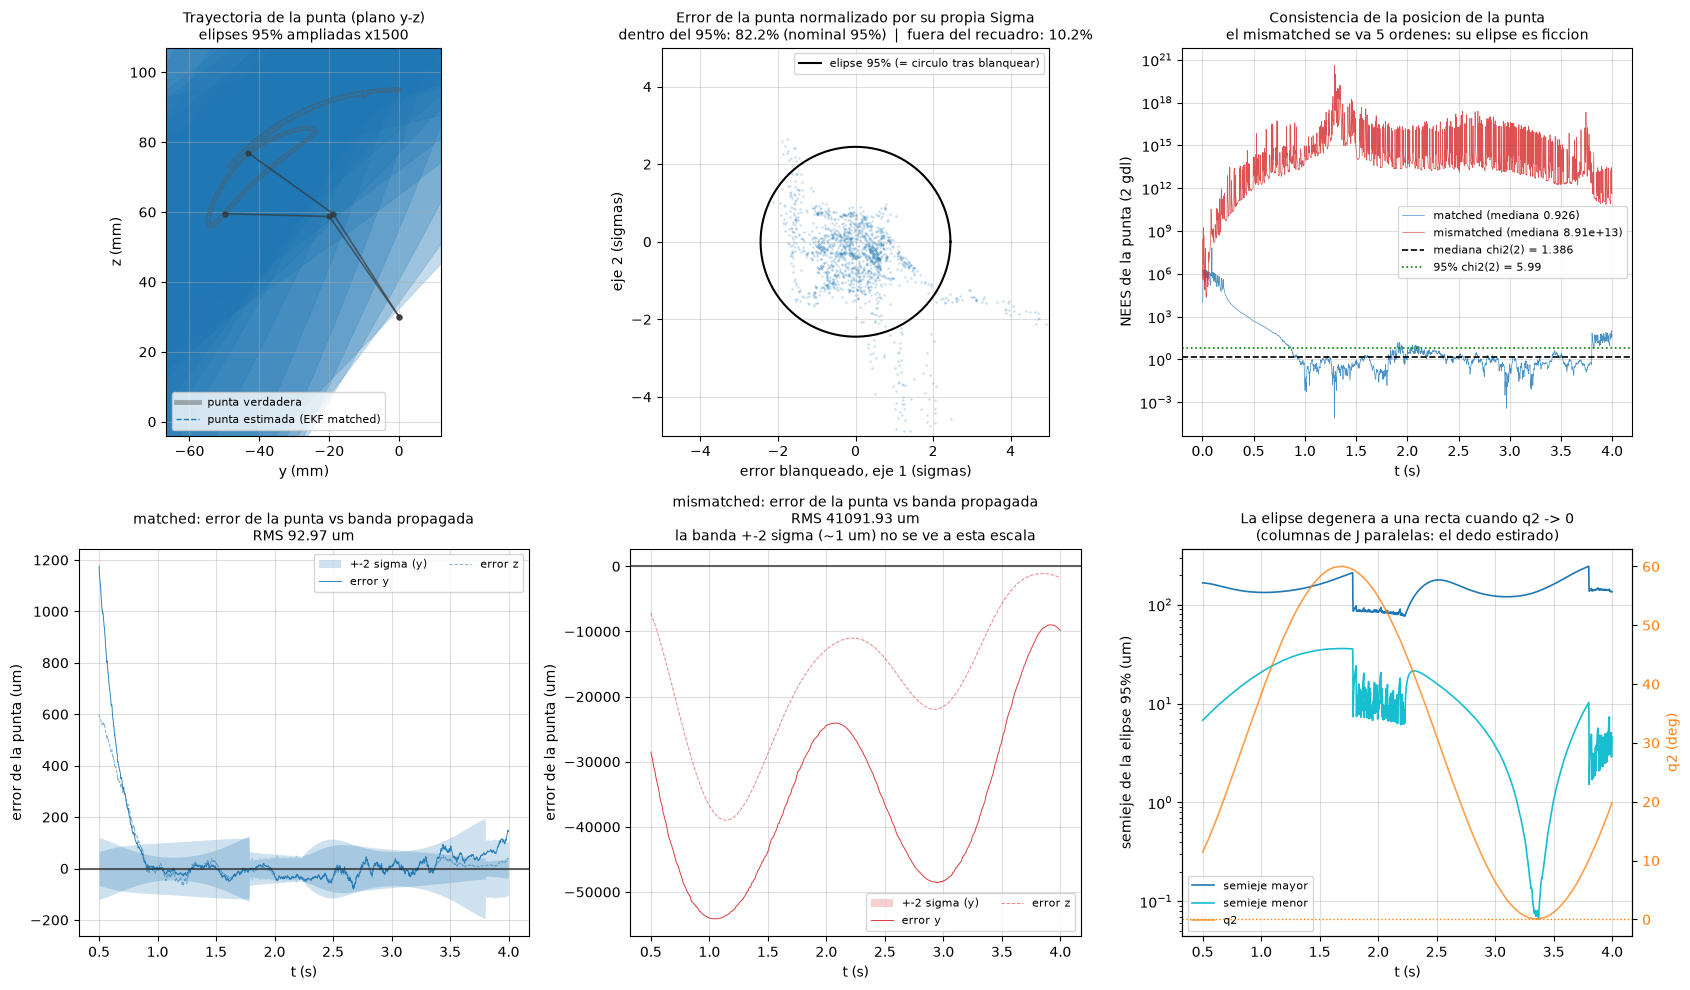

In [105]:
# ============================================================================
# La punta y su elipse de incertidumbre
# ============================================================================
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

ELL_SCALE = 1500          # la elipse mide micrones sobre un recorrido de 55 mm:
                          # sin ampliar es literalmente invisible. Va en el titulo.
t_tip = T_t[1:len(Z_meas)]
dm, dx = tip[LBL_M], tip[LBL_X]


def ellipse_patch(mean, cov, scale=1.0, **kw):
    """Elipse del 95% de una gaussiana 2D (radio^2 = chi2(2, 0.95) = 5.991)."""
    w, V = np.linalg.eigh(cov)
    w = np.clip(w, 0.0, None)
    ang = np.degrees(np.arctan2(V[1, -1], V[0, -1]))
    return Ellipse(mean, *(2 * np.sqrt(CHI2_2D_95 * w[::-1]) * scale), angle=ang, **kw)


fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# --- (0,0) trayectoria de la punta en el plano y-z --------------------------
ax = axes[0, 0]
ax.plot(dm["p_true"][:, 0] * 1e3, dm["p_true"][:, 1] * 1e3, color="0.35", lw=3.5,
        alpha=.45, label="punta verdadera")
ax.plot(dm["p_est"][:, 0] * 1e3, dm["p_est"][:, 1] * 1e3, "--", color="tab:blue", lw=1,
        label="punta estimada (EKF matched)")
# Solo en regimen permanente: en el transitorio P0 vale (3 deg)^2 y la elipse
# ampliada x1500 se sale de la figura por varios metros.
for k in range(int(np.argmax(ss)), len(dm["p_est"]), 60):
    ax.add_patch(ellipse_patch(dm["p_est"][k] * 1e3, dm["S"][k] * 1e6, ELL_SCALE,
                               facecolor="tab:blue", alpha=.25, edgecolor="tab:blue", lw=.5))
# El dedo dibujado en un par de poses: se ve que la elipse es casi perpendicular
# al eslabon distal, no una nube isotropa.
for k in (len(dm["p_est"]) // 3, 2 * len(dm["p_est"]) // 3):
    q = dm["q_est"][k]
    j1 = np.array([-L1 * np.sin(q[0]), L0 + L1 * np.cos(q[0])])
    ax.plot([0, j1[0] * 1e3, dm["p_est"][k, 0] * 1e3],
            [L0 * 1e3, j1[1] * 1e3, dm["p_est"][k, 1] * 1e3],
            "-o", color="0.2", lw=1.2, ms=3.5, alpha=.65)
ax.set_aspect("equal")
ax.set_xlim(dm["p_true"][:, 0].min() * 1e3 - 12, dm["p_true"][:, 0].max() * 1e3 + 12)
ax.set_ylim(-4, max(dm["p_true"][:, 1].max() * 1e3, L0 * 1e3) + 12)
ax.set_xlabel("y (mm)"); ax.set_ylabel("z (mm)")
ax.set_title(f"Trayectoria de la punta (plano y-z)\nelipses 95% ampliadas x{ELL_SCALE}", fontsize=10)
ax.legend(fontsize=8, loc="lower left"); ax.grid(True, alpha=.4)

# --- (0,1) error blanqueado: TODOS los errores contra UNA sola elipse -------
# S cambia en cada paso, asi que no se puede superponer una elipse sola sobre el
# error crudo. Blanqueando (e_w = L^-1 e con S = L L^T) la nube deberia ser
# N(0, I), y la elipse del 95% pasa a ser el circulo de radio sqrt(5.991).
ax = axes[0, 1]
ew = dm["e_w"][ss]
ax.scatter(ew[:, 0], ew[:, 1], s=3, alpha=.25, color="tab:blue", lw=0)
th = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.sqrt(CHI2_2D_95) * np.cos(th), np.sqrt(CHI2_2D_95) * np.sin(th),
        color="k", lw=1.5, label="elipse 95% (= circulo tras blanquear)")
LIM = 5.0
clipped = (np.abs(ew) > LIM).any(axis=1).mean()
ax.set_xlim(-LIM, LIM); ax.set_ylim(-LIM, LIM); ax.set_aspect("equal")
ax.set_xlabel("error blanqueado, eje 1 (sigmas)"); ax.set_ylabel("eje 2 (sigmas)")
ax.set_title(f"Error de la punta normalizado por su propia Sigma\n"
             f"dentro del 95%: {(dm['nees'][ss] <= CHI2_2D_95).mean():.1%} (nominal 95%)"
             f"  |  fuera del recuadro: {clipped:.1%}", fontsize=10)
ax.legend(fontsize=8, loc="upper right"); ax.grid(True, alpha=.4)

# --- (0,2) NEES de la punta, los dos filtros --------------------------------
ax = axes[0, 2]
for label, color, nm in ((LBL_M, "tab:blue", "matched"), (LBL_X, "tab:red", "mismatched")):
    ax.semilogy(t_tip, tip[label]["nees"], lw=.5, color=color, alpha=.8,
                label=f"{nm} (mediana {np.median(tip[label]['nees'][ss]):.3g})")
ax.axhline(chi2.ppf(0.5, 2), color="k", ls="--", lw=1.2, label="mediana chi2(2) = 1.386")
ax.axhline(CHI2_2D_95, color="g", ls=":", lw=1.2, label="95% chi2(2) = 5.99")
ax.set_xlabel("t (s)"); ax.set_ylabel("NEES de la punta (2 gdl)")
ax.set_title("Consistencia de la posicion de la punta\n"
             "el mismatched se va 5 ordenes: su elipse es ficcion", fontsize=10)
ax.legend(fontsize=8, loc="center right"); ax.grid(True, which="major", alpha=.4)

# --- (1,0) y (1,1) error por componente con banda +-2 sigma -----------------
for col, (label, color, nm) in enumerate(((LBL_M, "tab:blue", "matched"),
                                          (LBL_X, "tab:red", "mismatched"))):
    ax = axes[1, col]
    dd = tip[label]
    for j, (comp, ls) in enumerate((("y", "-"), ("z", "--"))):
        s = np.sqrt(dd["S"][:, j, j])
        ax.fill_between(t_tip[ss], -2 * s[ss] * 1e6, 2 * s[ss] * 1e6,
                        color=color, alpha=.22, lw=0,
                        label=f"+-2 sigma ({comp})" if j == 0 else None)
        ax.plot(t_tip[ss], dd["e"][ss, j] * 1e6, ls, color=color, lw=.7,
                alpha=.9 if j == 0 else .55, label=f"error {comp}")
    ax.axhline(0, color="0.15", lw=1.5, alpha=.7)
    ax.set_xlabel("t (s)"); ax.set_ylabel("error de la punta (um)")
    extra = "" if col == 0 else "\nla banda +-2 sigma (~1 um) no se ve a esta escala"
    ax.set_title(f"{nm}: error de la punta vs banda propagada\n"
                 f"RMS {np.linalg.norm(dd['e'][ss],axis=1).mean()*1e6:.2f} um{extra}", fontsize=10)
    ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=.4)

# --- (1,2) semiejes: la elipse degenera cuando el dedo se estira ------------
ax = axes[1, 2]
ev = np.clip(np.linalg.eigvalsh(dm["S"]), 0.0, None)
semi_ax = np.sqrt(CHI2_2D_95 * ev)
ax.semilogy(t_tip[ss], semi_ax[ss, 1] * 1e6, color="tab:blue", lw=1.2, label="semieje mayor")
ax.semilogy(t_tip[ss], np.maximum(semi_ax[ss, 0], 1e-18) * 1e6, color="tab:cyan", lw=1.2,
            label="semieje menor")
ax.set_xlabel("t (s)"); ax.set_ylabel("semieje de la elipse 95% (um)")
ax.set_title("La elipse degenera a una recta cuando q2 -> 0\n"
             "(columnas de J paralelas: el dedo estirado)", fontsize=10)
ax.grid(True, which="major", alpha=.4)
ax2 = ax.twinx()
ax2.plot(t_tip[ss], np.rad2deg(dm["q_est"][ss, 1]), color="tab:orange", lw=1.2, alpha=.75,
         label="q2")
ax2.axhline(0, color="tab:orange", ls=":", lw=1)
ax2.set_ylabel("q2 (deg)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="lower left")

fig.tight_layout()
plt.show()

### What the tip result says

**The blind filter localises the tip to ~59 µm over a 55 mm sweep** — 0.11% of
travel, against an actual RMS tip error of 93 µm. That is the honest price of not
knowing the command: the filter with `u` reached micrometres here. The band is the
right order, not the right number.

**The ellipse is nearly degenerate, and that is geometry, not a numerical
artefact.** Median aspect ratio 12:1, reaching 2067:1. Two uncertain angles, but
near $q_2 = 0$ the two columns of $J$ become parallel: both joints push the tip
along almost the same direction, and the uncertainty collapses onto a line. A
scalar "±59 µm" throws this away. The ellipse says *which way* the error points,
and near the straight-finger configuration that is the entire content of the
answer. It is also why the code uses `solve` rather than `inv`: `cond(S)` reaches
3.6e7.

**The tip inherits the `q` block, and the `q` block is no longer the problem.**
The NEES in tip space equals the NEES in angle space to 2e-10, which localises the
blame precisely — and it does *not* land on the kinematics or on `q`. The marginal
`q` NEES sits at 0.70x of target (slightly conservative), while the *full* state
NEES sits at ~8x. The excess lives in the directions that involve the activation:
exactly the ones that stopped being observable when `u` was withheld. Full-state
consistency and marginal consistency are different claims, and here they point in
opposite directions.

**A low median and a low coverage at the same time is not a contradiction.** The
95% ellipse covers 82%, yet the median tip NEES is 0.93 against a target of 1.386.
Both are true because the distribution is heavy-tailed: the weakly-observable
common mode leaves most steps comfortably inside the ellipse and sends a few far
outside. Reporting only the median would have hidden this; reporting only the
coverage would have suggested a uniformly optimistic band. The pair is the
diagnostic.

**For the 4-state cut the ellipse is pure fiction.** Tip error ~41 mm — most of
the finger's whole travel — against a propagated σ of 0.77 µm, a 14-order NEES
excess and 0.0% coverage. Propagating a covariance out of a biased filter yields a
confidently wrong answer, which is worse than no covariance at all: the number
looks usable.

**Dropping the `q1`–`q2` correlation is the error that hides in plain sight.** The
median correlation is only −0.037, and the 95% ellipse *area* changes by 1.00x —
so an area check certifies the wrong covariance as fine. What breaks is the
ellipse's orientation, and the worst-direction sigma is off by a median 1.08x and
up to 1.3x. This is precisely what is lost by storing `sqrt(diag(P))`.

**The first-order propagation is exact here, and that is a measurement.** Against
sigma points the error is 1e-6 at the real `P`, and it scales linearly with `|P|` —
the signature of a correctly-computed second-order remainder. It only becomes
significant at σ_q ≈ 60°, some 1000x the filter's actual uncertainty. So an
unscented transform on the output side would buy nothing at this operating point.
The Monte Carlo column floors at $\sqrt{2/n_{mc}}$, its own sampling noise — worth
knowing before reading it as agreement.


### Manual Implementation (Mine)

In [106]:
# ============================================================================
# Corrida propia: planta -> sensor -> filtro CIEGO, cada etapa por separado
# ============================================================================
# Se REUSAN plant_run / sensor_noise / run_filter de arriba, no se redefinen.
# Tampoco se pisa SIG_ACC a nivel de modulo: eso cambiaba el make_R de TODAS las
# celdas posteriores (incluida la propagacion a la punta) segun el orden en que
# se ejecutaran. El sensor mas ruidoso va como argumento local de make_R.
SIG_ACC_MINE, SIG_ALPHA_MINE, SIG_ACT_MINE = 3, 20.0, 0#1e-5

# 1. VERDAD: estado real de la planta + lectura ideal de los sensores.
X_Plant, Z_true_Plant, U_Plant, t_Plant = plant_run(
    3000, seed=0, sig_alpha=SIG_ALPHA_MINE, sig_act=SIG_ACT_MINE)

# 2. SENSOR: la lectura ruidosa, que ahora existe como dato y no se pierde.
R_Mine = make_R(model_sim, sig_acc=SIG_ACC_MINE)
Z_meas_Plant = sensor_noise(Z_true_Plant, seed=3, R=R_Mine)

# 3. FILTRO: CIEGO -- no recibe U_Plant, que queda solo como comando de la planta.
#    Va sobre model_blind, no sobre model_ekf: sin u, el recorte de 4 estados cree
#    que la fuerza es -kp*q - kv*v, un resorte que tira el dedo al cero, y se va
#    ~16 deg (esta medido en las falsaciones de la celda de la corrida canonica).
#    sig_alpha si se pasa explicito, para que el filtro asuma lo que la planta
#    hizo; con el default (12) creeria que hay mas ruido de proceso del que hay.
#    sig_act NO se pasa: el valor de la planta (SIG_ACT_MINE = 1e-5) es el jitter
#    alrededor de un setpoint conocido, y este filtro no conoce ninguno -> queda
#    SIG_ACT_BLIND, tres ordenes mas grande, que es el punto de make_Q_blind.
d_Mine = run_filter(model_blind, X_Plant, Z_meas_Plant, ROWS,
                    Q=make_Q_blind(model_blind, sig_alpha=SIG_ALPHA_MINE),
                    R=R_Mine)

# Chequeo barato de que el ruido inyectado es el que se pidio.
print("ruido medido (std) =", (Z_meas_Plant - Z_true_Plant)[:, ROWS].std(axis=0)[:3], "...")
print("sigma pedido       =", np.sqrt(np.diag(R_Mine))[ROWS][:3], "...")
print("verdad intacta     =", not np.shares_memory(Z_true_Plant, Z_meas_Plant))


ruido medido (std) = [3.001352 3.027396 2.938625] ...
sigma pedido       = [3. 3. 3.] ...
verdad intacta     = True


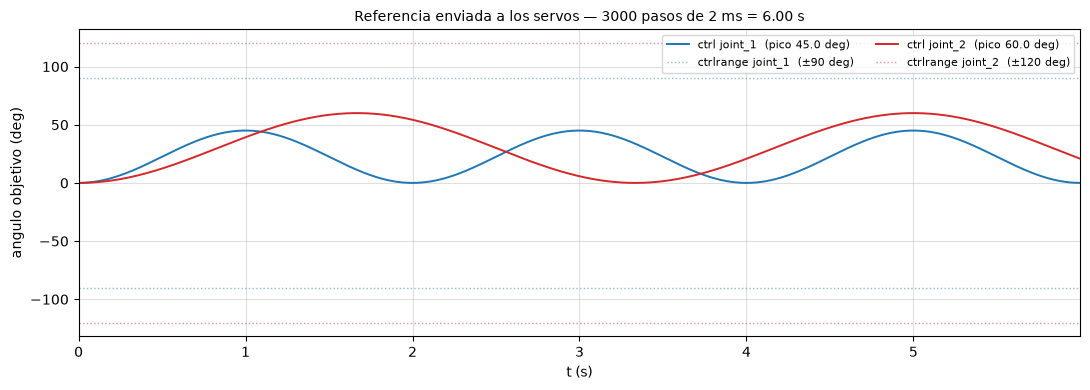

In [107]:
# ============================================================================
# Control aplicado a la planta: setpoint de cada servo
# ============================================================================
# U_Plant[k] = ctrl DURANTE [t_k, t_{k+1}] -> hay n valores para n+1 instantes,
# por eso t_Plant[:-1]. Es el angulo objetivo del servo (rad), no un torque:
# la fuerza sale de force = kp*(act - q) - kv*v dentro de MuJoCo.
# Las bandas son el ctrlrange compilado en el modelo (= recorrido del joint):
# si la referencia las tocara, MuJoCo la satura y la trayectoria deja de ser el
# raised cosine que se pidio.
colors = ("tab:blue", "tab:red")
names = ("joint_1", "joint_2")

fig, ax = plt.subplots(figsize=(11, 4))

for j in range(model_sim.nu):
    lo, hi = np.rad2deg(model_sim.actuator_ctrlrange[j])
    ax.plot(t_Plant[:-1], np.rad2deg(U_Plant[:, j]), color=colors[j], lw=1.4,
            label=f"ctrl {names[j]}  (pico {np.rad2deg(np.abs(U_Plant[:, j]).max()):.1f} deg)")
    ax.axhline(lo, color=colors[j], ls=":", lw=1, alpha=.5)
    ax.axhline(hi, color=colors[j], ls=":", lw=1, alpha=.5,
               label=f"ctrlrange {names[j]}  (±{hi:.0f} deg)")

ax.set_xlabel("t (s)")
ax.set_ylabel("angulo objetivo (deg)")
ax.set_title(f"Referencia enviada a los servos — {len(U_Plant)} pasos de "
             f"{dt_sim * 1000:.0f} ms = {t_Plant[-1]:.2f} s", fontsize=10)
ax.grid(True, alpha=.4)
ax.legend(fontsize=8, ncol=2, loc="upper right")
ax.margins(x=0)

fig.tight_layout()
plt.show()


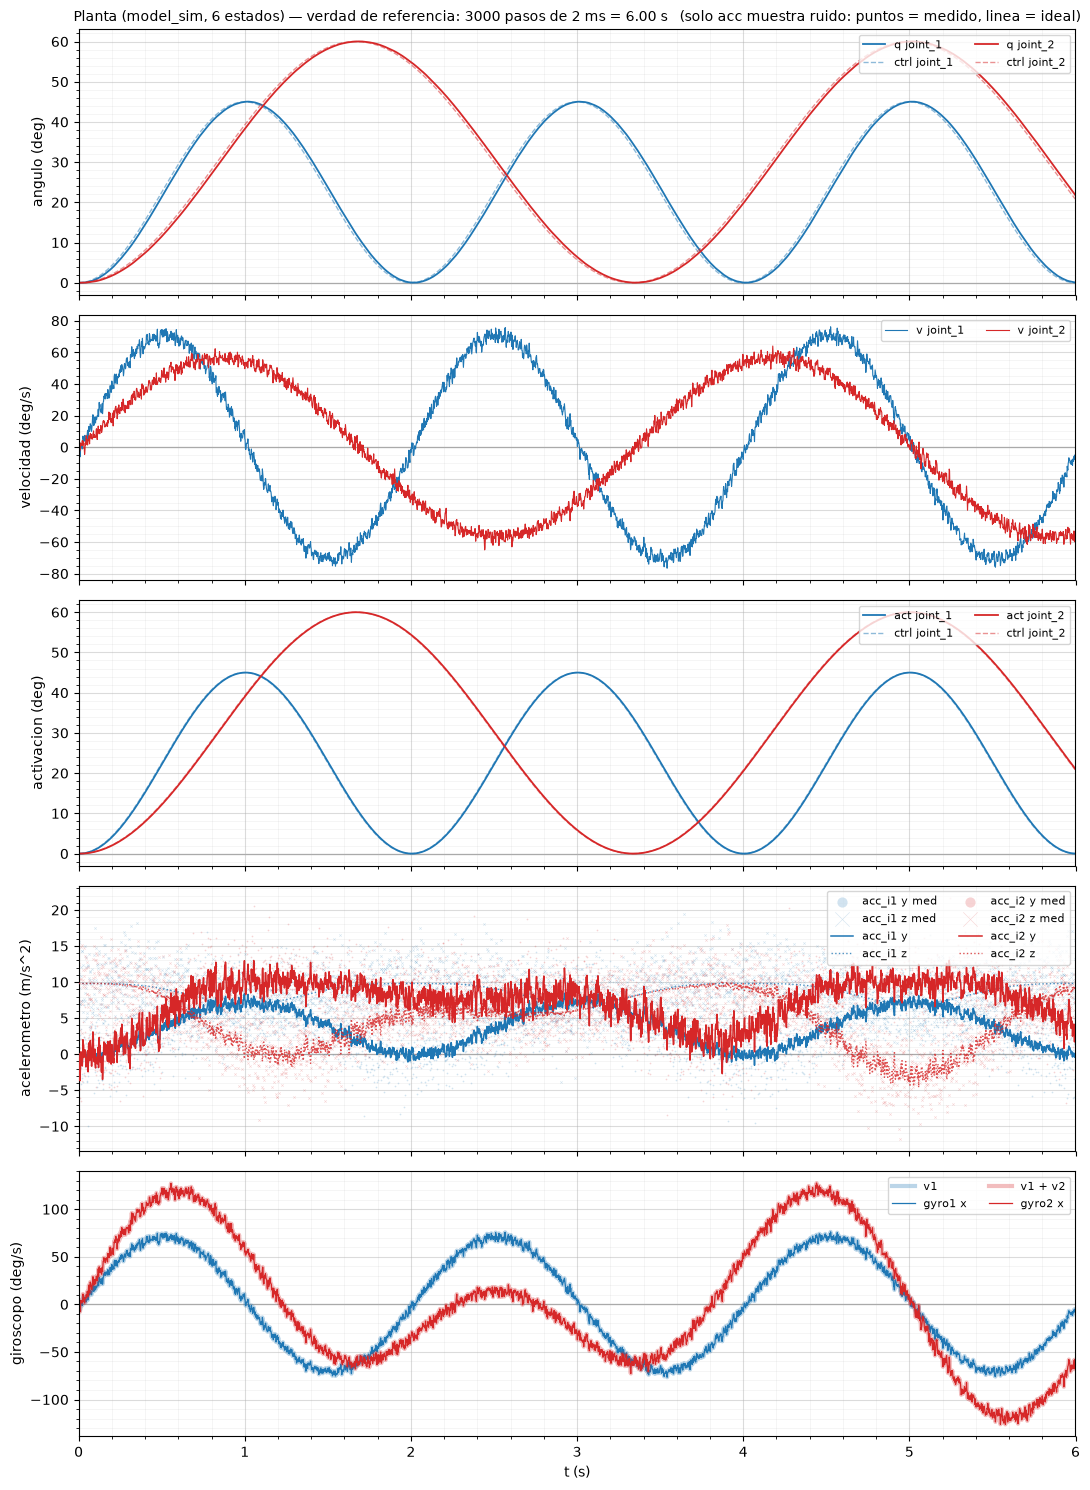

In [108]:
# ============================================================================
# Estado de la planta + lectura IDEAL de los sensores: un panel por unidad
# ============================================================================
# X_Plant[:, 0:2] = qpos, rad      -> angulo de cada joint
# X_Plant[:, 2:4] = qvel, rad/s    -> velocidad angular
# X_Plant[:, 4:6] = act,  rad      -> activacion del servo (setpoint pasado por
#                                     el filtro de 1er orden de constante tau)
# Z_true_Plant    = sensordata, SIN ruido -> lo que leeria un IMU perfecto.
# Z_meas_Plant    = esa misma lectura + ruido gaussiano (R_Mine, sig_acc = 3
#                   m/s^2) -> lo que el filtro efectivamente consume. Solo el
#                   panel de acelerometros la muestra, como scatter.
#
# Un solo plt.plot(t, X) mete todas las unidades en el mismo eje: qvel llega a
# cientos de deg/s y aplasta a los angulos contra el cero.
#
# Muestreo: X y t tienen n+1 muestras; U y Z solo n, porque se loguean ANTES de
# mj_step (el control actua DURANTE el paso) -> ambos van contra t_Plant[:-1].
#
# Que componentes se grafican y por que las otras no: el dedo es planar (los dos
# hinges giran sobre x), asi que de los 3 canales de cada sensor sobran algunos.
#   acelerometro: x == 0 identicamente; quedan y, z
#   giroscopo:    y == z == 0; queda x
# Y el giroscopo reproduce EXACTO la velocidad articular (verificado a 1e-16):
#   gyro1_x = v1        el IMU proximal ve la velocidad del joint 1
#   gyro2_x = v1 + v2   el distal ve la ACUMULADA, no la del joint 2
# Por eso un giro montado en el eslabon distal informa sobre los DOS angulos, y
# por eso las filas de H de gyro2 no son cero en la columna de v1.
nv = model_sim.nv
colors = ("tab:blue", "tab:red")
names = ("joint_1", "joint_2")
imus = (("acc_i1", "gyro1"), ("acc_i2", "gyro2"))     # indexado por joint
t_s = t_Plant[:-1]                                    # eje de U y de Z

fig, axes = plt.subplots(5, 1, figsize=(11, 15), sharex=True)

for j in range(nv):
    c = colors[j]
    acc_nm, gyr_nm = imus[j]
    # --- angulo real vs referencia: incluye lag del servo Y dinamica del eslabon
    axes[0].plot(t_Plant, np.rad2deg(X_Plant[:, j]), color=c, lw=1.3,
                 label=f"q {names[j]}")
    axes[0].plot(t_s, np.rad2deg(U_Plant[:, j]), color=c, lw=1,
                 ls="--", alpha=.5, label=f"ctrl {names[j]}")
    # --- velocidad: es donde se ve el ruido de proceso (sig_alpha)
    axes[1].plot(t_Plant, np.rad2deg(X_Plant[:, nv + j]), color=c, lw=.8,
                 label=f"v {names[j]}")
    # --- activacion vs ctrl: aca el unico desfase es tau, sin la mecanica
    axes[2].plot(t_Plant, np.rad2deg(X_Plant[:, 2 * nv + j]), color=c, lw=1.3,
                 label=f"act {names[j]}")
    axes[2].plot(t_s, np.rad2deg(U_Plant[:, j]), color=c, lw=1,
                 ls="--", alpha=.5, label=f"ctrl {names[j]}")
    # --- acelerometros: fuerza ESPECIFICA, incluye gravedad (a dedo quieto el
    #     canal z lee ~9.81, no 0). Unico panel con las DOS cosas: la medicion
    #     (Z_meas_Plant) va como scatter y la lectura ideal (Z_true_Plant) como
    #     linea. Dibujar las dos como linea no sirve: con sig_acc = 3 m/s^2 la
    #     ruidosa es una banda que tapa a la limpia, y lo que hay que poder leer
    #     es justamente cuanto las separa. y = puntos + solida, z = cruces +
    #     punteada. La linea va por encima (zorder) para no perderla en la nube.
    a0 = sensor_slice(acc_nm).start
    axes[3].scatter(t_s, Z_meas_Plant[:, a0 + 1], color=c, s=1.5, alpha=.20,
                    marker="o", linewidths=0, zorder=2, label=f"{acc_nm} y med")
    axes[3].scatter(t_s, Z_meas_Plant[:, a0 + 2], color=c, s=3, alpha=.20,
                    marker="x", linewidths=.4, zorder=2, label=f"{acc_nm} z med")
    axes[3].plot(t_s, Z_true_Plant[:, a0 + 1], color=c, lw=1.1, zorder=3,
                 label=f"{acc_nm} y")
    axes[3].plot(t_s, Z_true_Plant[:, a0 + 2], color=c, lw=1, ls=":", alpha=.8,
                 zorder=3, label=f"{acc_nm} z")
    # --- giroscopos contra la velocidad que TIENEN que reproducir: la curva
    #     gruesa palida es el estado, la fina es el sensor. Se tapan exactamente.
    v_ref = X_Plant[:-1, nv] if j == 0 else X_Plant[:-1, nv] + X_Plant[:-1, nv + 1]
    axes[4].plot(t_s, np.rad2deg(v_ref), color=c, lw=3, alpha=.30,
                 label="v1" if j == 0 else "v1 + v2")
    axes[4].plot(t_s, np.rad2deg(Z_true_Plant[:, sensor_slice(gyr_nm).start]),
                 color=c, lw=.9, label=f"{gyr_nm} x")

axes[0].set_ylabel("angulo (deg)")
axes[0].set_title(f"Planta (model_sim, 6 estados) — verdad de referencia: "
                  f"{len(t_Plant) - 1} pasos de {dt_sim * 1000:.0f} ms "
                  f"= {t_Plant[-1]:.2f} s   (solo acc muestra ruido: "
                  f"puntos = medido, linea = ideal)", fontsize=10)
axes[1].set_ylabel("velocidad (deg/s)")
axes[2].set_ylabel("activacion (deg)")
axes[3].set_ylabel("acelerometro (m/s^2)")
axes[4].set_ylabel("giroscopo (deg/s)")
axes[4].set_xlabel("t (s)")

for ax in axes:
    # Grilla en dos niveles: la mayor para ubicarse, la menor para poder LEER
    # valores (con dt = 2 ms y 1000 pasos, una sola grilla gruesa no alcanza
    # para decir en que instante pasa algo). El cero va aparte: es la referencia
    # de signo, tanto para el angulo como para la velocidad.
    ax.minorticks_on()
    ax.grid(True, which="major", alpha=.45, lw=.8)
    ax.grid(True, which="minor", alpha=.18, lw=.5)
    ax.axhline(0, color="k", lw=.9, alpha=.35, zorder=1)
    ax.legend(fontsize=8, ncol=2, loc="upper right", markerscale=6)
    ax.margins(x=0)

fig.tight_layout()
plt.show()


RMS error q = [0.035501 0.105386] deg   sigma_P = [0.105292 0.380418] deg
RMS error v = [0.284034 0.404077] deg/s sigma_P = [0.285983 0.404806] deg/s
NEES mediana = 208.33 (objetivo 6)   NIS media = 10.19 (objetivo 12)
comando recuperado |a_hat - u| = [1.851517 0.945186] deg  (sobre un barrido de [45. 60.] deg)


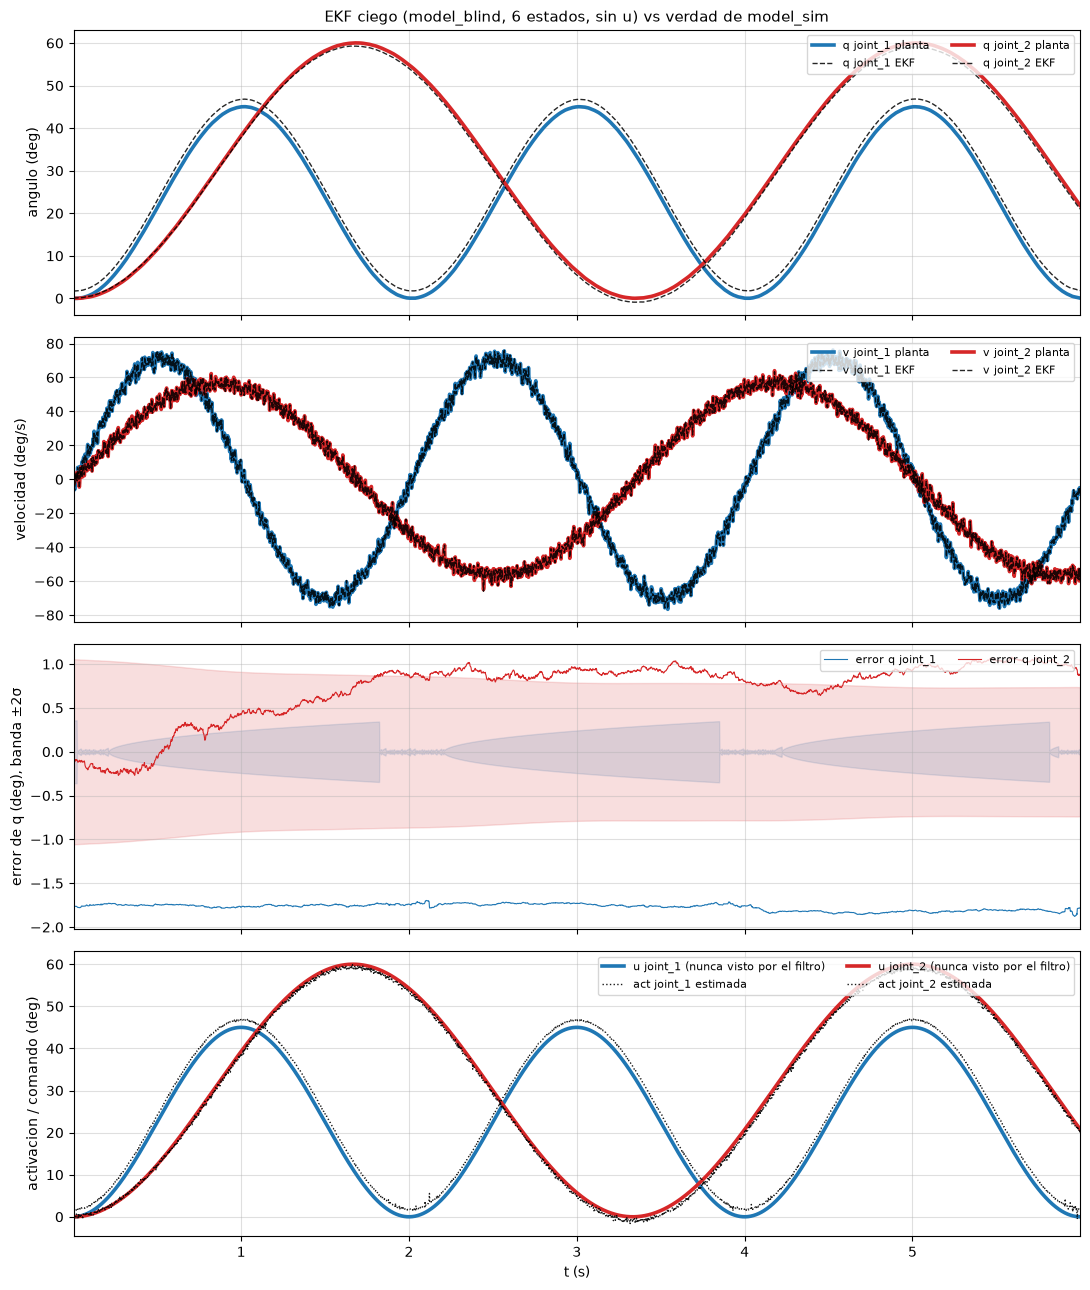

In [109]:
# ============================================================================
# Estimacion del EKF vs verdad de la planta
# ============================================================================
# Alineacion: el loop de run_filter arranca en k = 1, asi que xh[0] es la
# estimacion en t_1, no en t_0 -> t_Plant[1:K+1], NO t_Plant[:-2] (esa tiene el
# largo correcto pero corre la curva un paso entero hacia atras).
# model_blind -> nx = 6: estima tambien las 2 activaciones, que es lo unico que
# le permite correr sin u. Los paneles muestran q y v; la activacion recuperada
# es la que se compara contra U_Plant en el cuarto panel.
# La verdad va por blind_reference: con actearly, la activacion en vigor durante
# el paso k es a_{k+1}, y es esa la que el filtro estima.
nees, nis, err, sP, xh = (d_Mine["nees"], d_Mine["nis"], d_Mine["err"],
                          d_Mine["sig"], d_Mine["xh"])

K = len(xh)
t = t_Plant[1:K + 1]
ref = blind_reference(X_Plant, model_blind)[1:K + 1, :xh.shape[1]]
h = K // 2                                    # segunda mitad: sin transitorio

print(f"RMS error q = {np.rad2deg(err[h:, :2]).std(axis=0)} deg   "
      f"sigma_P = {np.rad2deg(sP[h:, :2].mean(axis=0))} deg")
print(f"RMS error v = {np.rad2deg(err[h:, 2:4]).std(axis=0)} deg/s "
      f"sigma_P = {np.rad2deg(sP[h:, 2:4].mean(axis=0))} deg/s")
print(f"NEES mediana = {np.median(nees[h:]):.2f} (objetivo {xh.shape[1]})   "
      f"NIS media = {nis[h:].mean():.2f} (objetivo {ROWS.size})")

# El comando recuperado: lo unico que este filtro produce y el de arriba no.
# a_hat es la activacion estimada; U_Plant es el setpoint que el filtro NUNCA vio.
lag_free = np.abs(xh[h:, 4:6] - U_Plant[1 + h:1 + K, :]).mean(axis=0)
print(f"comando recuperado |a_hat - u| = {np.rad2deg(lag_free)} deg  "
      f"(sobre un barrido de {np.rad2deg(np.ptp(U_Plant, axis=0))} deg)")

colors, names = ("tab:blue", "tab:red"), ("joint_1", "joint_2")
fig, axes = plt.subplots(4, 1, figsize=(11, 13), sharex=True)

for j in range(2):
    c = colors[j]
    # La verdad va SOLIDA y a color pleno; la estimacion, negra y punteada
    # encima. Antes ambas eran del mismo color y la verdad iba palida: donde el
    # filtro seguia bien no se distinguia cual curva era cual.
    axes[0].plot(t, np.rad2deg(ref[:, j]), color=c, lw=2.6, zorder=2,
                 label=f"q {names[j]} planta")
    axes[0].plot(t, np.rad2deg(xh[:, j]), color="k", lw=1.0, ls="--", alpha=.85,
                 zorder=3, label=f"q {names[j]} EKF")
    axes[1].plot(t, np.rad2deg(ref[:, 2 + j]), color=c, lw=2.6, zorder=2,
                 label=f"v {names[j]} planta")
    axes[1].plot(t, np.rad2deg(xh[:, 2 + j]), color="k", lw=1.0, ls="--", alpha=.85,
                 zorder=3, label=f"v {names[j]} EKF")
    # unico panel que permite JUZGAR: a esta escala el overlay siempre "da bien"
    axes[2].plot(t, np.rad2deg(err[:, j]), color=c, lw=.8, label=f"error q {names[j]}")
    axes[2].fill_between(t, -2 * np.rad2deg(sP[:, j]), 2 * np.rad2deg(sP[:, j]),
                         color=c, alpha=.15)
    # El filtro no vio U_Plant en ningun momento: lo reconstruye desde el
    # movimiento, que es lo que compra llevar la activacion como estado.
    axes[3].plot(t, np.rad2deg(U_Plant[1:K + 1, j]), color=c, lw=2.6, zorder=2,
                 label=f"u {names[j]} (nunca visto por el filtro)")
    axes[3].plot(t, np.rad2deg(xh[:, 4 + j]), color="k", lw=1.0, ls=":", alpha=.9,
                 zorder=3, label=f"act {names[j]} estimada")

axes[0].set_ylabel("angulo (deg)")
axes[1].set_ylabel("velocidad (deg/s)")
axes[2].set_ylabel("error de q (deg), banda ±2σ")
axes[3].set_ylabel("activacion / comando (deg)")
axes[3].set_xlabel("t (s)")
axes[0].set_title("EKF ciego (model_blind, 6 estados, sin u) vs verdad de model_sim",
                  fontsize=11)
for ax in axes:
    ax.grid(True, alpha=.4)
    ax.legend(fontsize=8, ncol=2, loc="upper right")
    ax.margins(x=0)

fig.tight_layout()
plt.show()


canal acc_i2[1] = fila 13 de sensordata
  |z_meas - z_true| medio =   2.4008 m/s^2   ruido de sensor inyectado
  |z_pred - z_true| medio =   3.1096 m/s^2   error del PRIOR del filtro
  sesgo de h en el canal  =   0.0000 m/s^2   MODELO, no ruido
  -> pierde el prior. Si |sesgo| >> sigma del sensor, es culpa del modelo


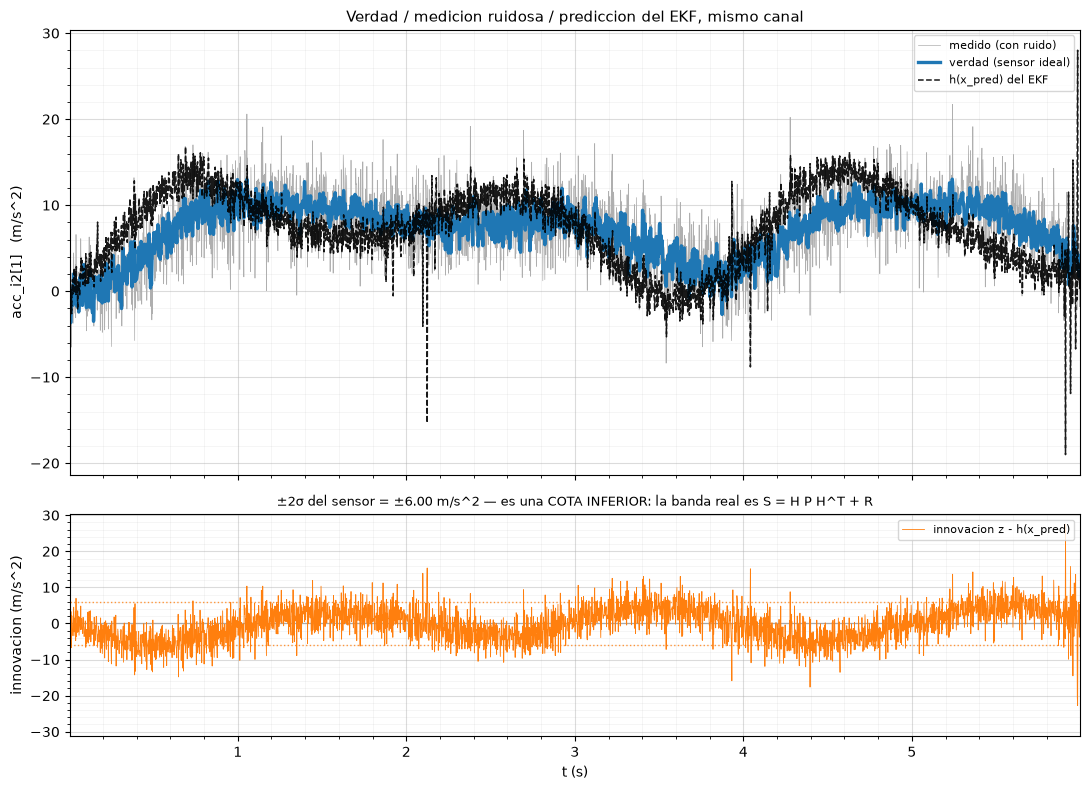

In [110]:
# ============================================================================
# Los tres objetos, en espacio de MEDICION: verdad / ruidosa / prediccion
# ============================================================================
# Aca es donde el triple se ve de verdad. En espacio de estado no hay "estado
# ruidoso" con que comparar; en espacio de medicion los tres existen:
#   Z_true_Plant      lo que el sensor leeria si fuera perfecto
#   Z_meas_Plant      lo que efectivamente leyo  (verdad + ruido)
#   d_Mine["z_pred"]  h(x_pred): lo que el EKF creia que iba a leer
# z_pred es el prior: h(x_pred), ANTES de ver z_k. Que le gane o no a la medicion
# cruda depende de la relacion entre error de PREDICCION y ruido de sensor.
#
# Sacarle u al filtro dio vuelta este panel, y conviene decirlo con los numeros
# medidos sobre acc_i2_y (SIG_ALPHA_MINE=20, SIG_ACC_MINE=3):
#   con u (como estaba antes):  |z_pred - z_true| = 0.86  vs  |z_meas - z_true| = 2.40
#                               -> ganaba el PRIOR
#   ciego (ahora):              |z_pred - z_true| = 2.91  vs  |z_meas - z_true| = 2.40
#                               -> gana la MEDICION
# El error del prior se triplica (0.86 -> 2.91 m/s^2) y ese factor ES la actuacion
# desconocida: en un paso el filtro no sabe que torque le van a aplicar.
#
# Y no se arregla con mejor sensor. Barriendo sig_acc con el filtro ciego, el
# error del prior se queda clavado en ~2.9 m/s^2 (0.05 -> 2.91, 0.5 -> 2.93,
# 3.0 -> 3.11) porque lo fija SIG_ALPHA y la actuacion que no se ve, no R. Asi
# que aca la medicion gana para TODO sig_acc probado. Con u, en cambio, bastaba
# ensuciar el sensor para que ganara el prior.
# Eso ES la ganancia de Kalman: con R chico frente a H P H^T, K tiende a 1 y el
# filtro le cree al sensor. Lo que si se ve siempre es que z_pred es SUAVE: no
# copia el ruido, que es la diferencia entre filtrar y repetir la medicion.
CANAL = ("acc_i2", 1)                       # (sensor, componente) -> acc_i2 eje y
ch = sensor_slice(CANAL[0]).start + CANAL[1]
i_ch = int(np.where(ROWS == ch)[0][0])      # posicion del canal dentro de ROWS

K = len(d_Mine["xh"])
t = t_Plant[1:K + 1]                        # los arrays del filtro arrancan en k = 1
z_true = Z_true_Plant[1:K + 1, ch]
z_meas = Z_meas_Plant[1:K + 1, ch]
z_pred = d_Mine["z_pred"][:, i_ch]

# El prior puede perder contra la medicion cruda por DOS motivos distintos, y
# conviene medir cual es: (a) el sensor es bueno frente al ruido de proceso -- sano,
# es la ganancia de Kalman tendiendo a 1; (b) h esta sesgado porque el modelo del
# filtro no es el de la planta -- eso ningun Q lo arregla.
e_meas, e_pred = np.abs(z_meas - z_true).mean(), np.abs(z_pred - z_true).mean()
_dm = mj.MjData(model_blind)
_Xr = blind_reference(X_Plant, model_blind)
bias_ch = np.mean([Z_true_Plant[k, ch]
                   - h_dyn(_Xr[k, :state_dim(model_blind)], np.zeros(model_blind.nu),
                           model_blind, _dm)[ch]
                   for k in range(1, K, 25)])
print(f"canal {CANAL[0]}[{CANAL[1]}] = fila {ch} de sensordata")
print(f"  |z_meas - z_true| medio = {e_meas:8.4f} m/s^2   ruido de sensor inyectado")
print(f"  |z_pred - z_true| medio = {e_pred:8.4f} m/s^2   error del PRIOR del filtro")
print(f"  sesgo de h en el canal  = {bias_ch:8.4f} m/s^2   MODELO, no ruido")
print("  " + ("-> el prior le gana a la medicion: sensor ruidoso frente al proceso"
              if e_pred < e_meas else
              "-> pierde el prior. Si |sesgo| >> sigma del sensor, es culpa del modelo"))

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=(2, 1)))

axes[0].plot(t, z_meas, color="0.65", lw=.5, alpha=.9, zorder=1,
             label="medido (con ruido)")
axes[0].plot(t, z_true, color="tab:blue", lw=2.4, zorder=2,
             label="verdad (sensor ideal)")
axes[0].plot(t, z_pred, color="k", lw=1.1, ls="--", alpha=.9, zorder=3,
             label="h(x_pred) del EKF")
axes[0].set_ylabel(f"{CANAL[0]}[{CANAL[1]}]   (m/s^2)")
axes[0].set_title("Verdad / medicion ruidosa / prediccion del EKF, mismo canal",
                  fontsize=11)

# Innovacion: z_meas - z_pred, que es lo unico que el filtro llega a corregir.
sig_z = np.sqrt(R_Mine[ch, ch])
axes[1].plot(t, d_Mine["innov"][:, i_ch], color="tab:orange", lw=.6,
             label="innovacion z - h(x_pred)")
axes[1].axhline(0, color="k", lw=.9, alpha=.35, zorder=1)
for s in (-2, 2):
    axes[1].axhline(s * sig_z, color="tab:orange", ls=":", lw=1, alpha=.8)
axes[1].set_ylabel("innovacion (m/s^2)")
axes[1].set_xlabel("t (s)")
axes[1].set_title(f"±2σ del sensor = ±{2 * sig_z:.2f} m/s^2 — es una COTA INFERIOR: "
                  "la banda real es S = H P H^T + R", fontsize=9)

for ax in axes:
    ax.minorticks_on()
    ax.grid(True, which="major", alpha=.45, lw=.8)
    ax.grid(True, which="minor", alpha=.18, lw=.5)
    ax.legend(fontsize=8, loc="upper right")
    ax.margins(x=0)

fig.tight_layout()
plt.show()
